# Прогнозирование повторной госпитализации пациента

## 1. Подготовка и анализ данных

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.api.types import is_object_dtype
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GroupShuffleSplit, StratifiedGroupKFold
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from imblearn.combine import SMOTETomek, SMOTEENN
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score, recall_score, accuracy_score, precision_score, confusion_matrix, roc_auc_score, roc_curve
import shap
from imblearn.pipeline import Pipeline as ImbPipeline


In [2]:
import warnings
from sklearn.exceptions import UndefinedMetricWarning
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

### 1. Считывание данных и первичный обзор

In [3]:
df = pd.read_csv('diabetic_data.csv', encoding='utf8', sep=',')
df.head(10)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,35754,82637451,Caucasian,Male,[50-60),?,2,1,2,3,...,No,Steady,No,No,No,No,No,No,Yes,>30
6,55842,84259809,Caucasian,Male,[60-70),?,3,1,2,4,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
7,63768,114882984,Caucasian,Male,[70-80),?,1,1,7,5,...,No,No,No,No,No,No,No,No,Yes,>30
8,12522,48330783,Caucasian,Female,[80-90),?,2,1,4,13,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
9,15738,63555939,Caucasian,Female,[90-100),?,3,3,4,12,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
df.shape

(101766, 50)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [6]:
print(f'Список всех колонок: {df.columns.to_list()}')

Список всех колонок: ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [7]:
numeric_column = []
object_column = []

for column in df:
    if is_object_dtype(df[column].dtype):
        object_column.append(column)
    else:
        numeric_column.append(column)

print('-'*60)
print(f'Категориальные признаки: \n{object_column} \nКоличество столбцов:{len(object_column)}')
print('-'*60)
print(f'Количественные признаки: \n{numeric_column} \nКоличество столбцов:{len(numeric_column)}')
print('-'*60)

------------------------------------------------------------
Категориальные признаки: 
['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'] 
Количество столбцов:37
------------------------------------------------------------
Количественные признаки: 
['encounter_id', 'patient_nbr', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'nu

In [8]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


### 2. Преобразование целевой переменной

In [9]:
readmitted_map = {'NO': 0, '>30': 0, '<30': 1}
df['readmitted'] = df['readmitted'].map(readmitted_map)

### 3. Анализ баланса классов, дубликатов и пропусков.

#### 3.1. Дубликаты строк:

In [10]:
duplicates_id = df.duplicated(subset=['encounter_id'])
duplicates_nbr = df.duplicated(subset=['patient_nbr'])
l1, l2 = 0, 0
for is_duplicate in duplicates_id:
    if is_duplicate == True:
        l1 += 1
print(f'Количество дубликатов по encounter_id: {l1}')

patient_counts = df['patient_nbr'].value_counts()
print(f'Количество уникальных пациентов: {df["patient_nbr"].nunique()}')
print(f'Количество пациентов с несколькими госпитализациями: {(patient_counts > 1).sum()}')

Количество дубликатов по encounter_id: 0
Количество уникальных пациентов: 71518
Количество пациентов с несколькими госпитализациями: 16773


#### 3.2. Баланс классов:

In [11]:
df['readmitted'].value_counts(normalize=True)

readmitted
0    0.888401
1    0.111599
Name: proportion, dtype: float64

В 8 раз перевес класса 0 (повторной госпитализации в течение 30 дней не происходило).

#### 3.3. Пропуски категориальных признаков:

In [12]:
df = df.replace(['?', 'Unknown/Invalid', 'nan'], np.nan)
df.dropna(subset=['gender'], inplace=True)
df = df.reset_index(drop=True)

y_split = df['readmitted']
groups_split = df['patient_nbr']

gss_test = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_val_idx, test_idx = next(gss_test.split(df, y_split, groups=groups_split))

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx_rel, val_idx_rel = next(
    gss_val.split(
        df.iloc[train_val_idx],
        y_split.iloc[train_val_idx],
        groups=groups_split.iloc[train_val_idx]
    )
)

train_idx = train_val_idx[train_idx_rel]
val_idx = train_val_idx[val_idx_rel]


In [13]:
one_value = []
str_nan = {}
print('-'*80)
uniq = []
for i in range(len(object_column)):
    print(f'**Название столбца: {object_column[i]}')
    print(f'Количество уникальных значений: {len(df[object_column[i]].unique())}')
    if len(df[object_column[i]].unique()) == 1:
        one_value.append(object_column[i])
    print(df[object_column[i]].unique())
    missing_idx = df.loc[df[object_column[i]].isna()].index.tolist()
    print(df[object_column[i]].value_counts())
    print(f'Количество пропусков:{len(missing_idx)}')
    print('-'*80)
    if len(missing_idx) != 0:
        str_nan[object_column[i]] = len(missing_idx)


--------------------------------------------------------------------------------
**Название столбца: race
Количество уникальных значений: 6
['Caucasian' 'AfricanAmerican' nan 'Other' 'Asian' 'Hispanic']
race
Caucasian          76099
AfricanAmerican    19210
Hispanic            2037
Other               1505
Asian                641
Name: count, dtype: int64
Количество пропусков:2271
--------------------------------------------------------------------------------
**Название столбца: gender
Количество уникальных значений: 2
['Female' 'Male']
gender
Female    54708
Male      47055
Name: count, dtype: int64
Количество пропусков:0
--------------------------------------------------------------------------------
**Название столбца: age
Количество уникальных значений: 10
['[0-10)' '[10-20)' '[20-30)' '[30-40)' '[40-50)' '[50-60)' '[60-70)'
 '[70-80)' '[80-90)' '[90-100)']
age
[70-80)     26066
[60-70)     22482
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)    

In [14]:
print('Только одно значение во всем столбце')
print(one_value)

Только одно значение во всем столбце
['examide', 'citoglipton']


In [15]:
print('Столбцы с пропусками:')
print(str_nan)

Столбцы с пропусками:
{'race': 2271, 'weight': 98566, 'payer_code': 40255, 'medical_specialty': 49947, 'diag_1': 21, 'diag_2': 358, 'diag_3': 1423, 'max_glu_serum': 96417, 'A1Cresult': 84745}


#### 3.4. Пропуски количественных признаков

In [16]:
one_value2 = []
str_nan2 = {}
print('-'*80)
for i in range(len(numeric_column)):
    print(f'**Название столбца: {numeric_column[i]}')
    print(f'Количество уникальных значений: {len(df[numeric_column[i]].unique())}')
    if len(df[numeric_column[i]].unique()) == 1:
        one_value2.append(numeric_column[i])
    print(df[numeric_column[i]].unique())
    missing_idx = df.loc[df[numeric_column[i]].isna()].index.tolist()
    print(f'Количество пропусков:{len(missing_idx)}')
    print('-'*80)
    if len(missing_idx) != 0:
        str_nan2[numeric_column[i]] = len(missing_idx)

--------------------------------------------------------------------------------
**Название столбца: encounter_id
Количество уникальных значений: 101763
[  2278392    149190     64410 ... 443854148 443857166 443867222]
Количество пропусков:0
--------------------------------------------------------------------------------
**Название столбца: patient_nbr
Количество уникальных значений: 71515
[  8222157  55629189  86047875 ... 140199494 120975314 175429310]
Количество пропусков:0
--------------------------------------------------------------------------------
**Название столбца: admission_type_id
Количество уникальных значений: 8
[6 1 2 3 4 5 8 7]
Количество пропусков:0
--------------------------------------------------------------------------------
**Название столбца: discharge_disposition_id
Количество уникальных значений: 26
[25  1  3  6  2  5 11  7 10  4 14 18  8 13 12 16 17 22 23  9 20 15 24 28
 19 27]
Количество пропусков:0
-----------------------------------------------------------

In [17]:
print('Только одно значение во всем столбце')
print(one_value2)

Только одно значение во всем столбце
[]


In [18]:
print('Столбцы с пропусками (количественные):')
print(str_nan2)

Столбцы с пропусками (количественные):
{}


### 4. Распределение количественных признаков по целевой группе

Удаляем 'encounter_id' из анализа признаков. 'patient_nbr' также не является признаком модели, но сохраняется до разделения выборки, чтобы госпитализации одного пациента не попадали одновременно в train, validation и test.

In [19]:
numeric_column.remove('encounter_id')
numeric_column.remove('patient_nbr')

In [20]:
print(numeric_column)

['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']


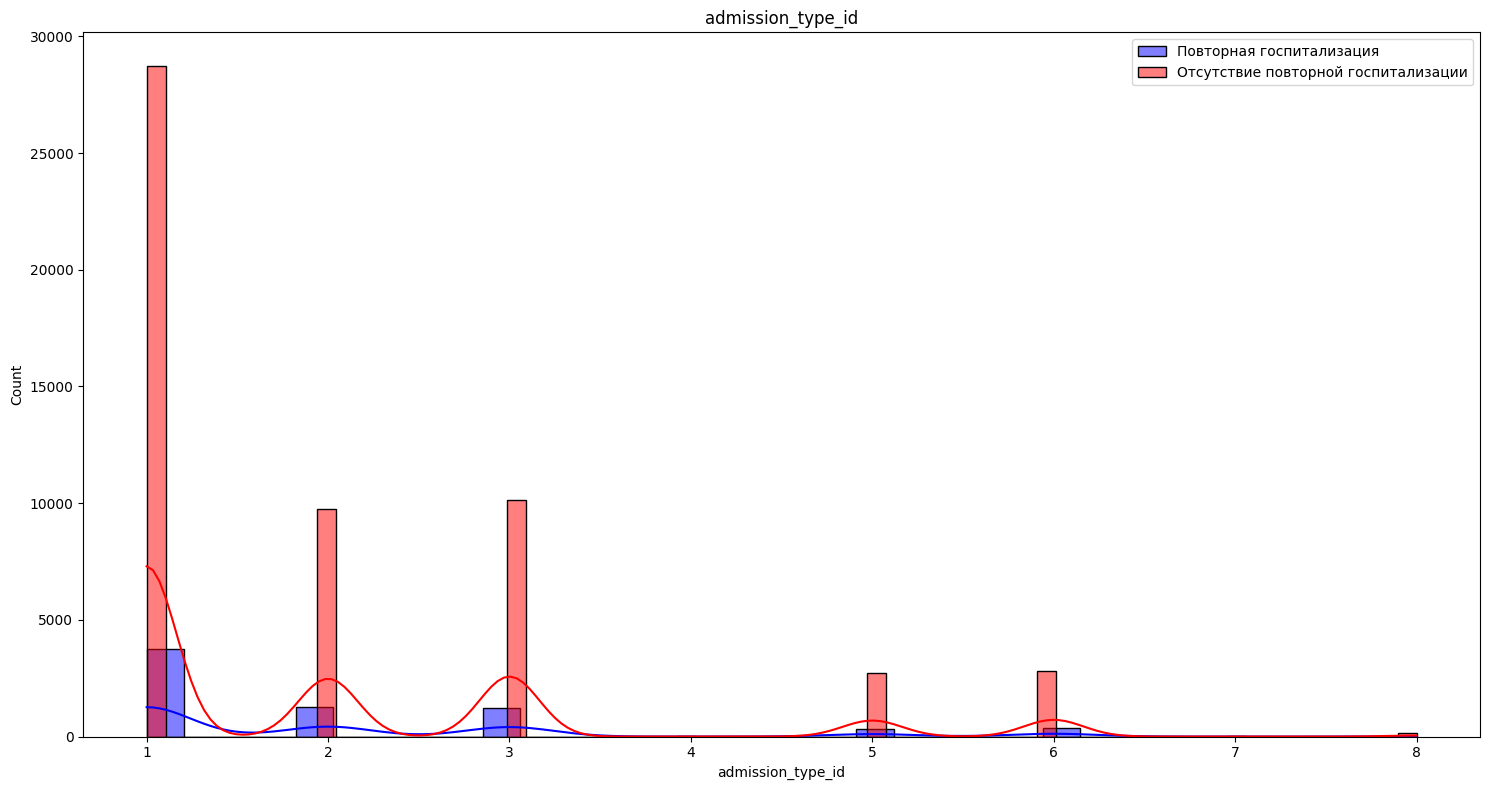

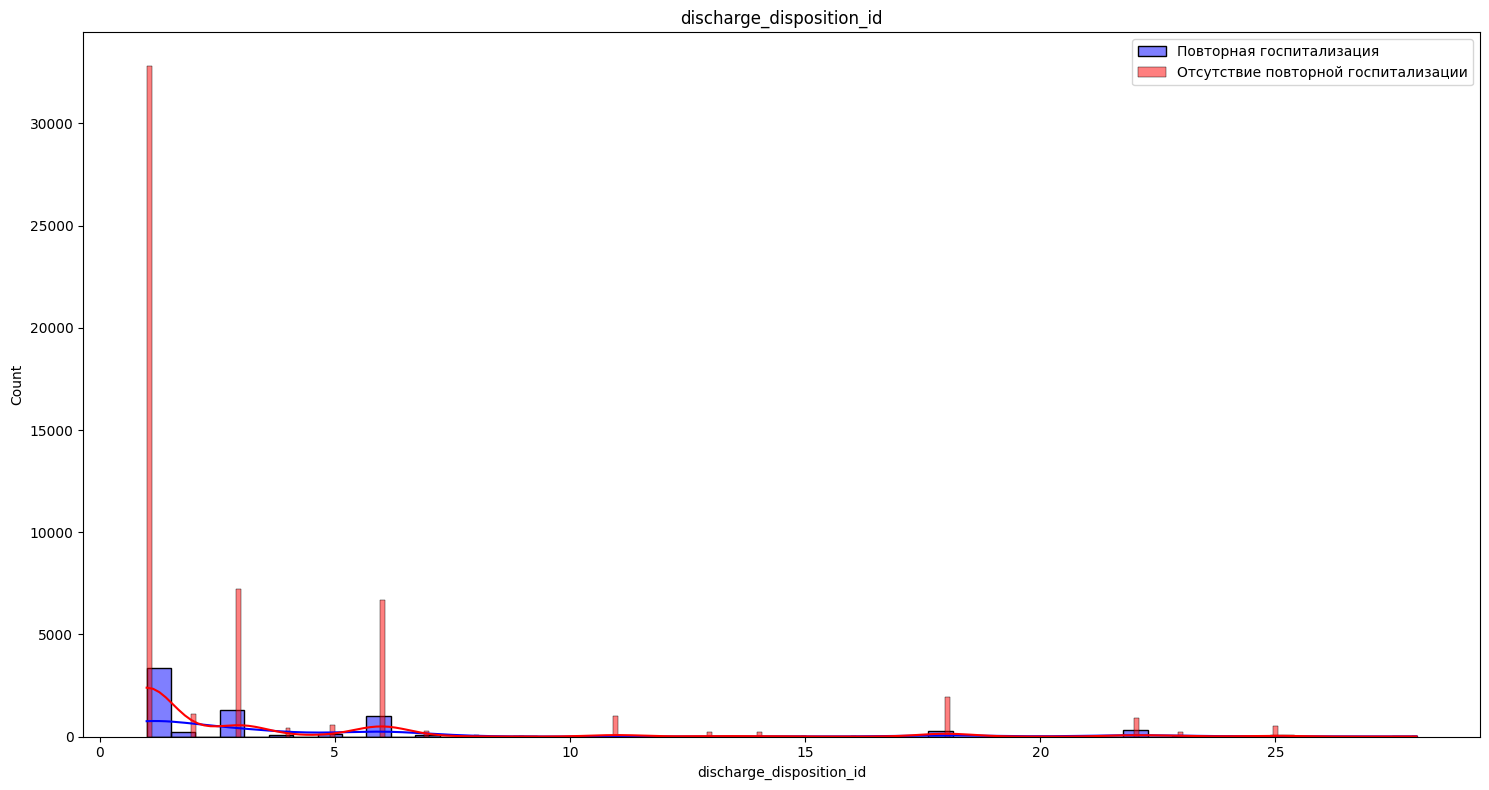

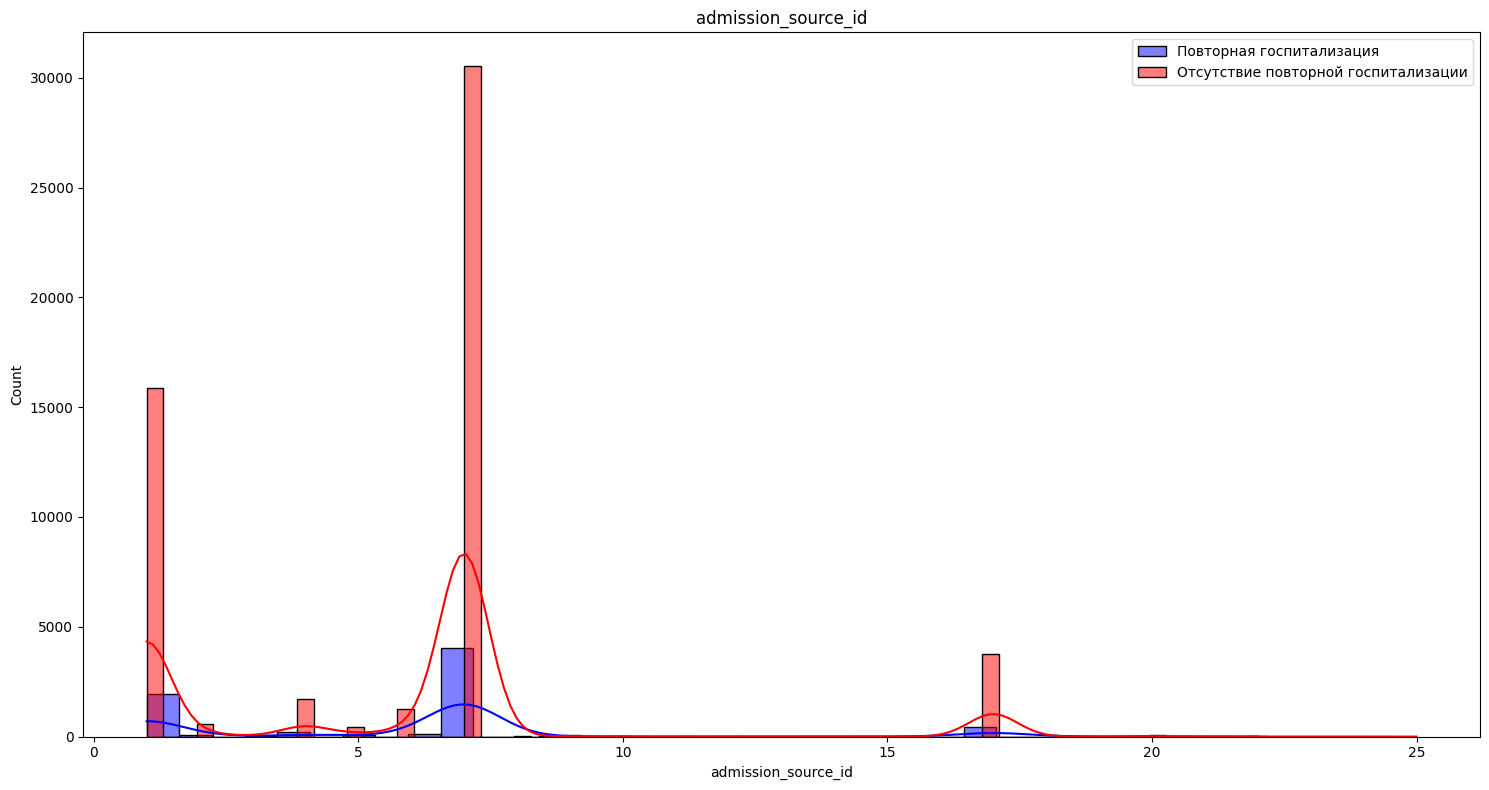

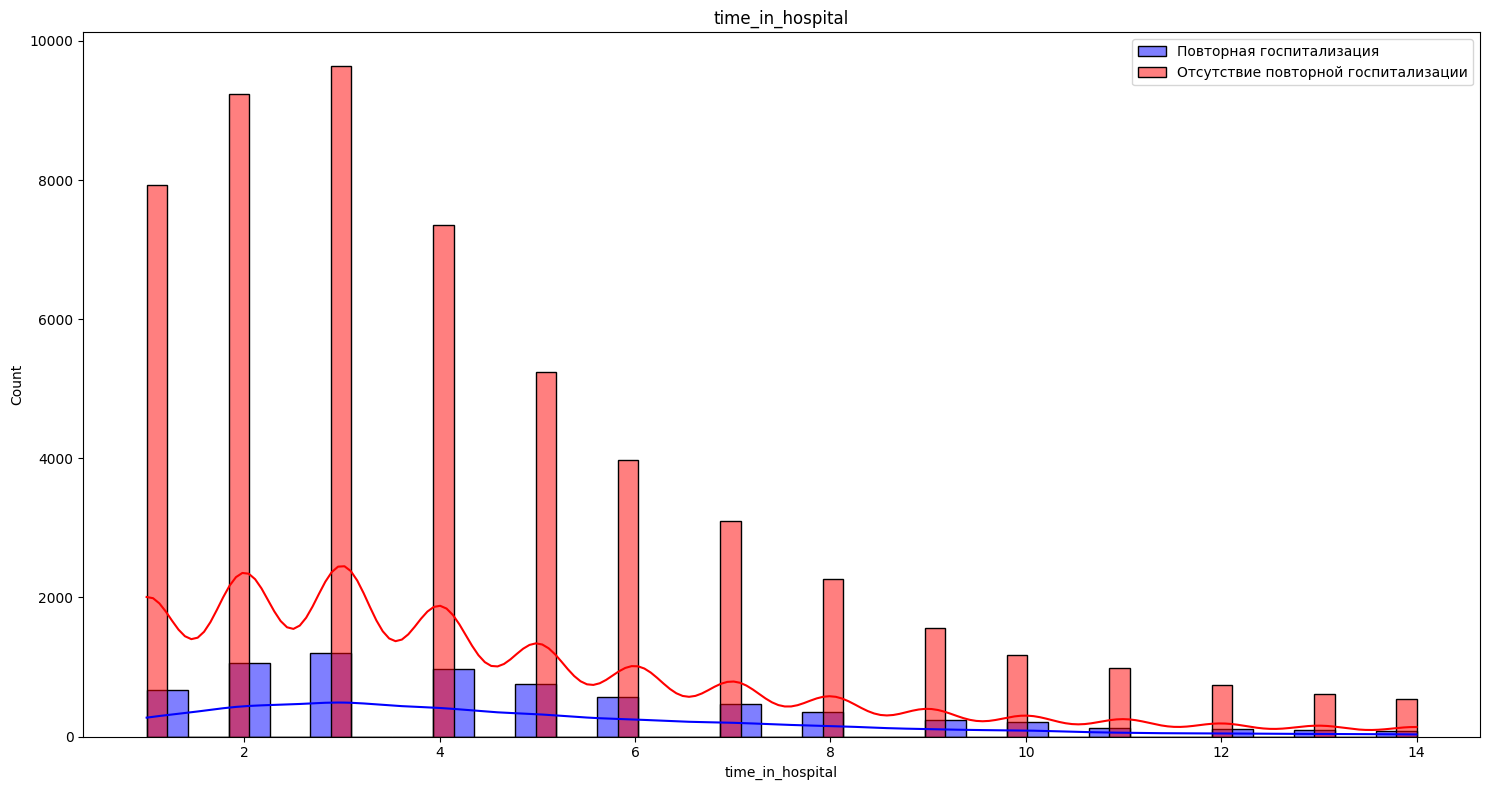

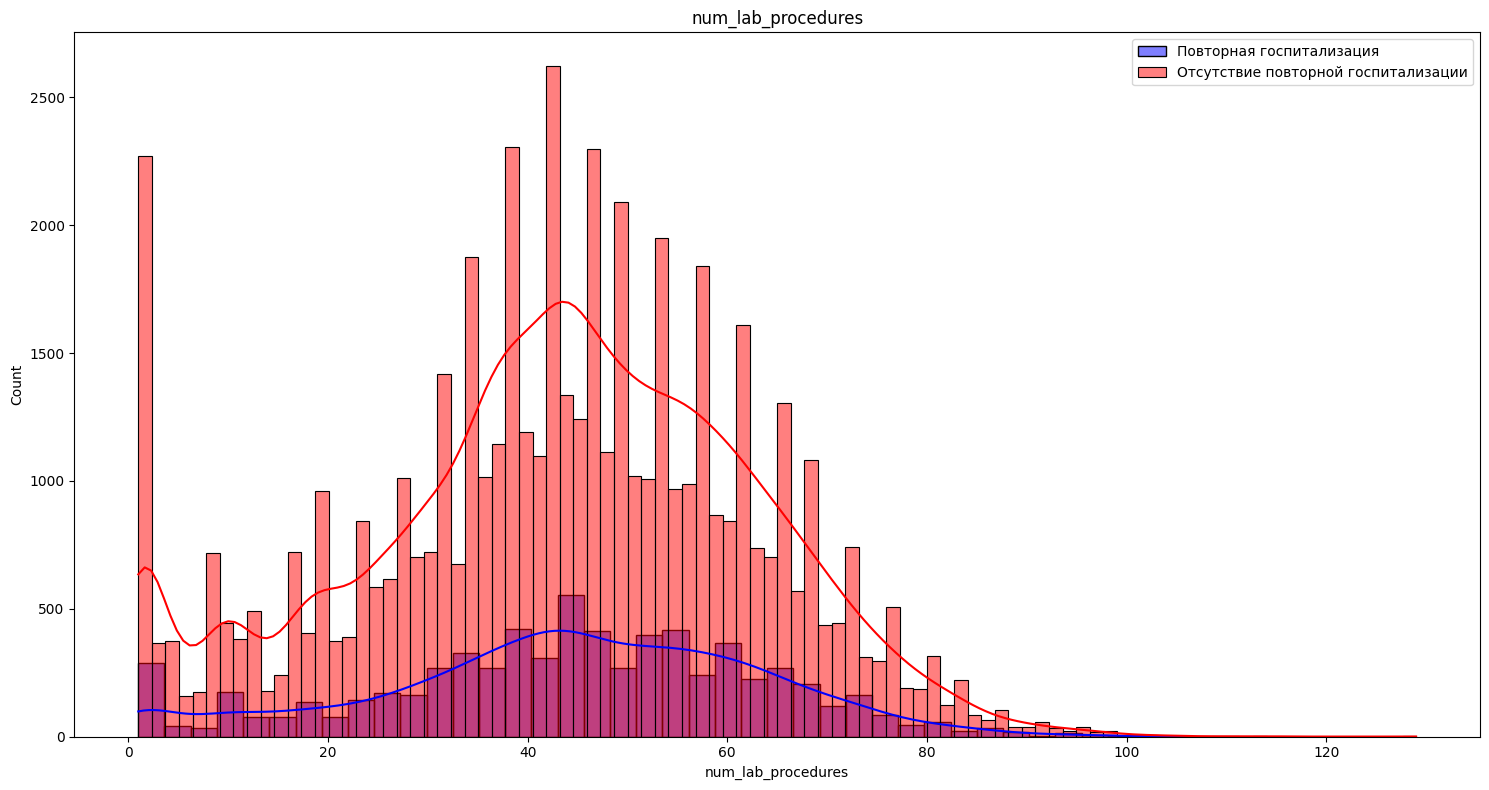

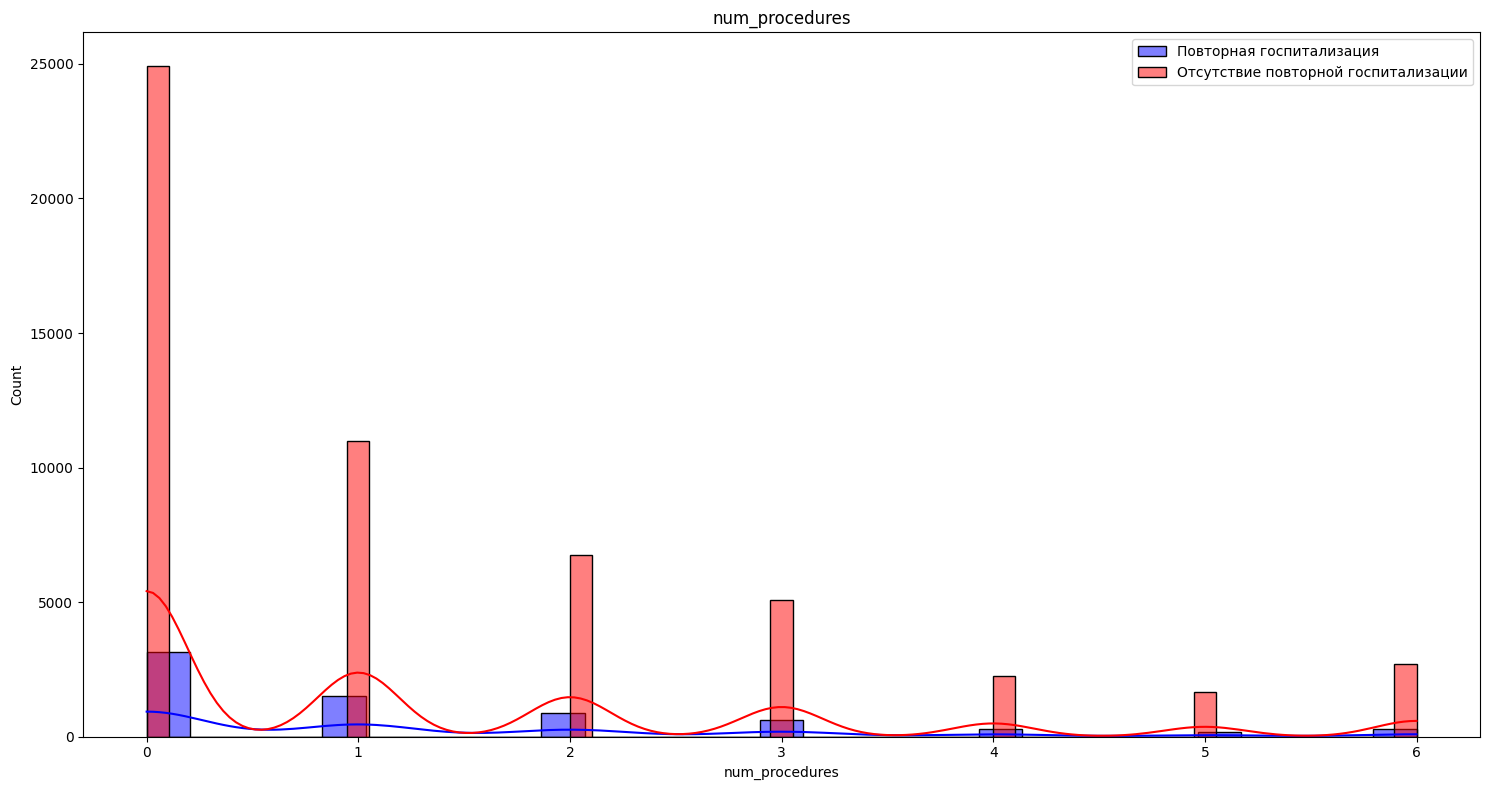

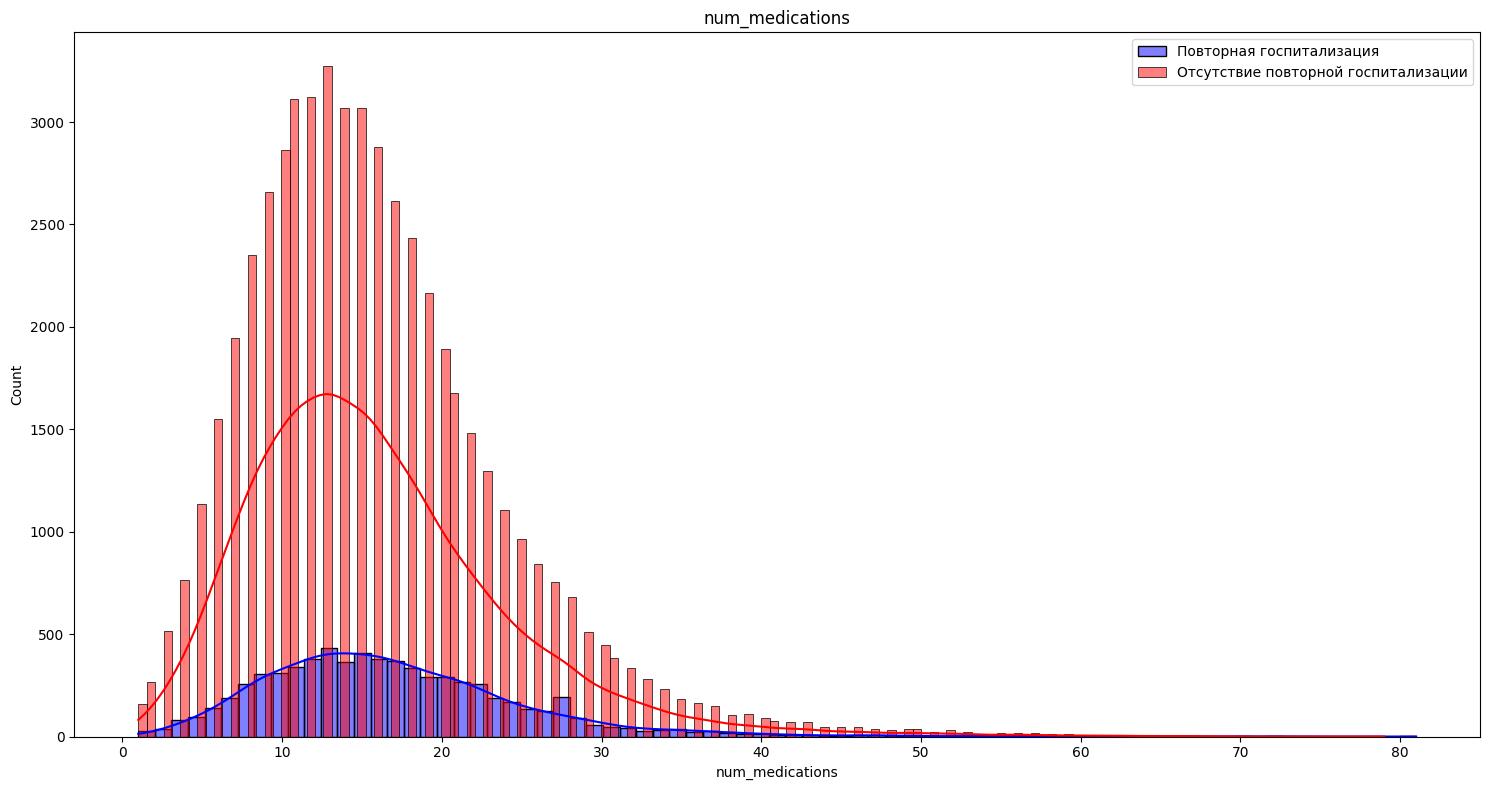

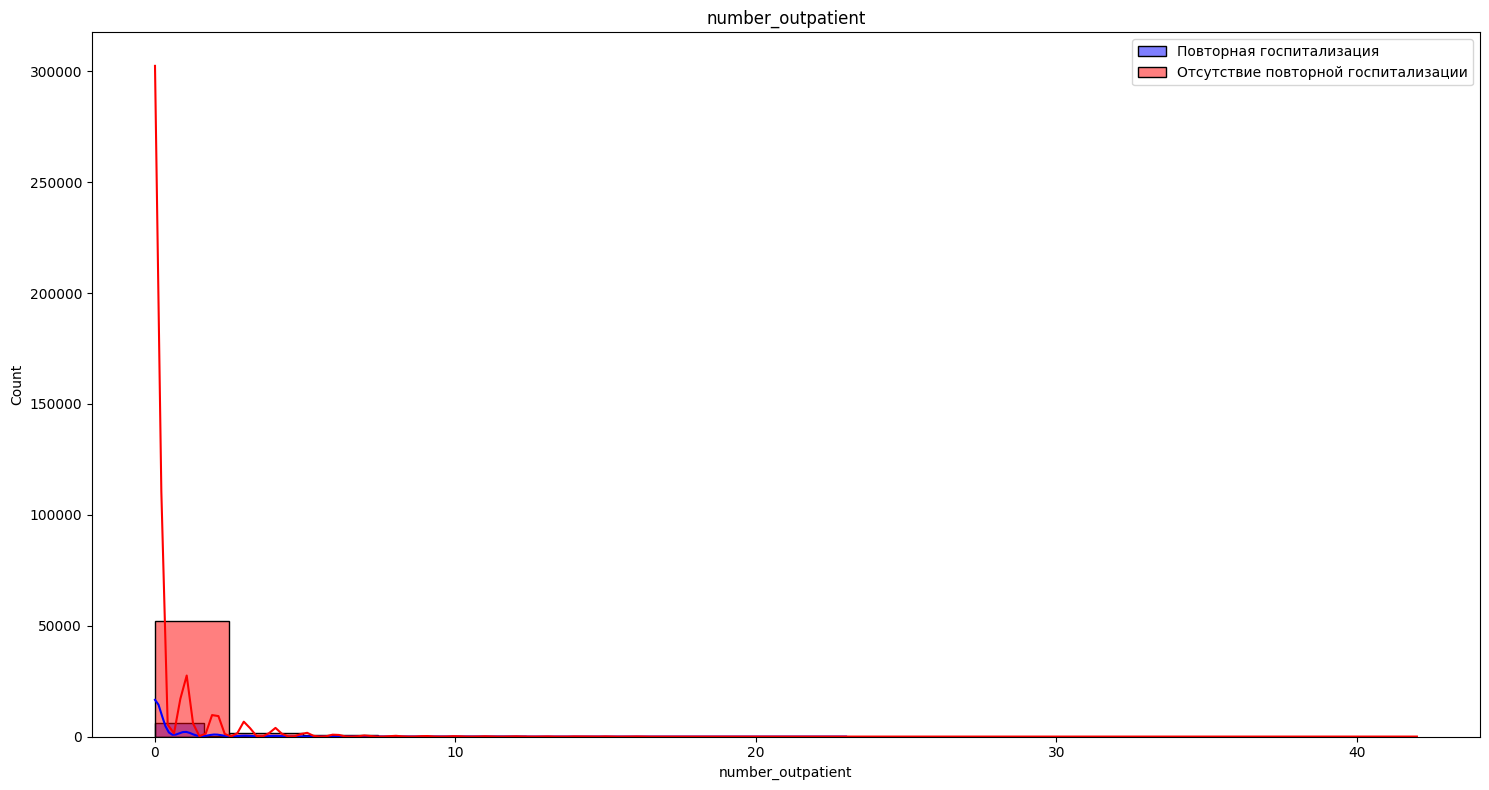

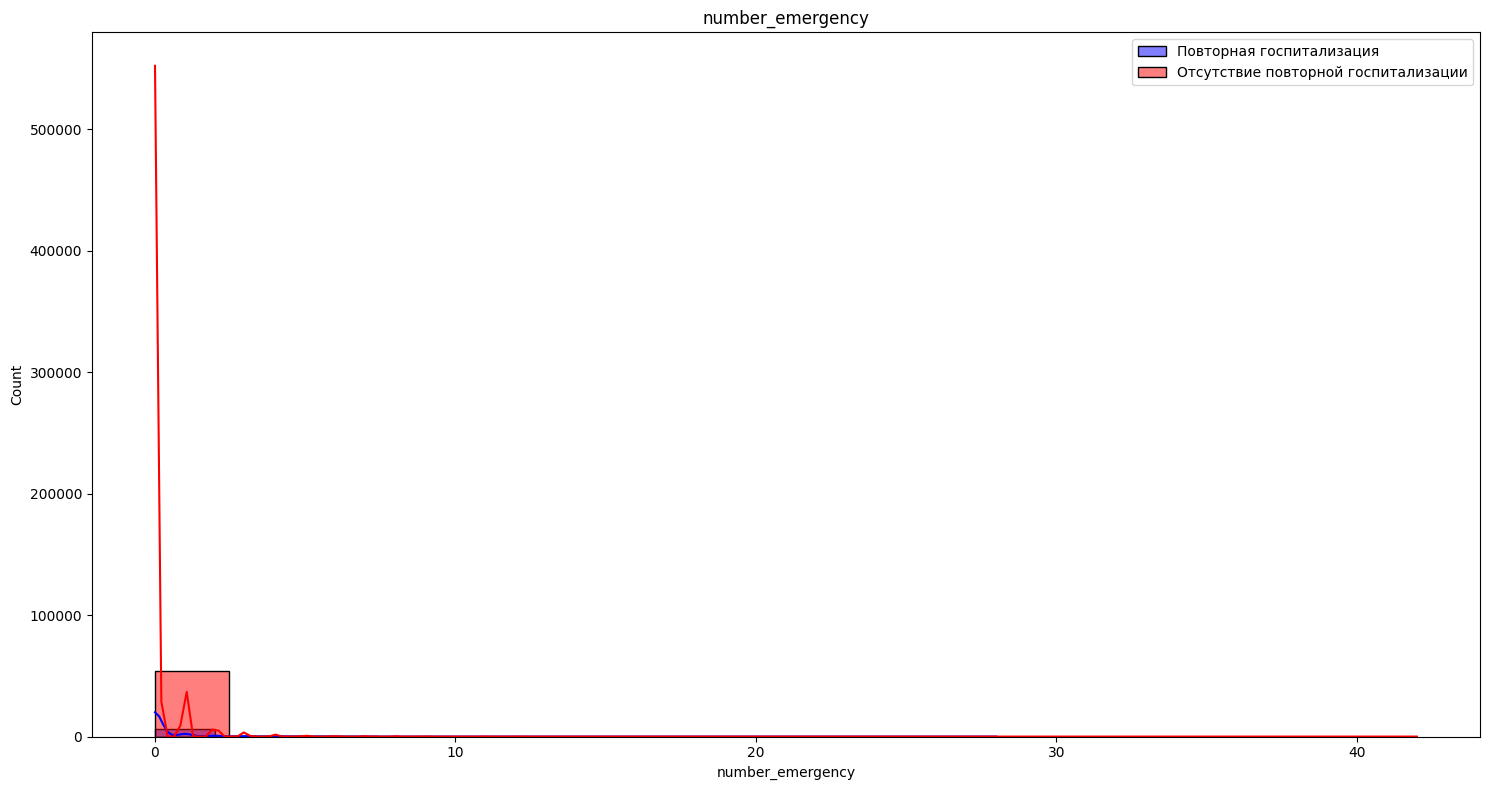

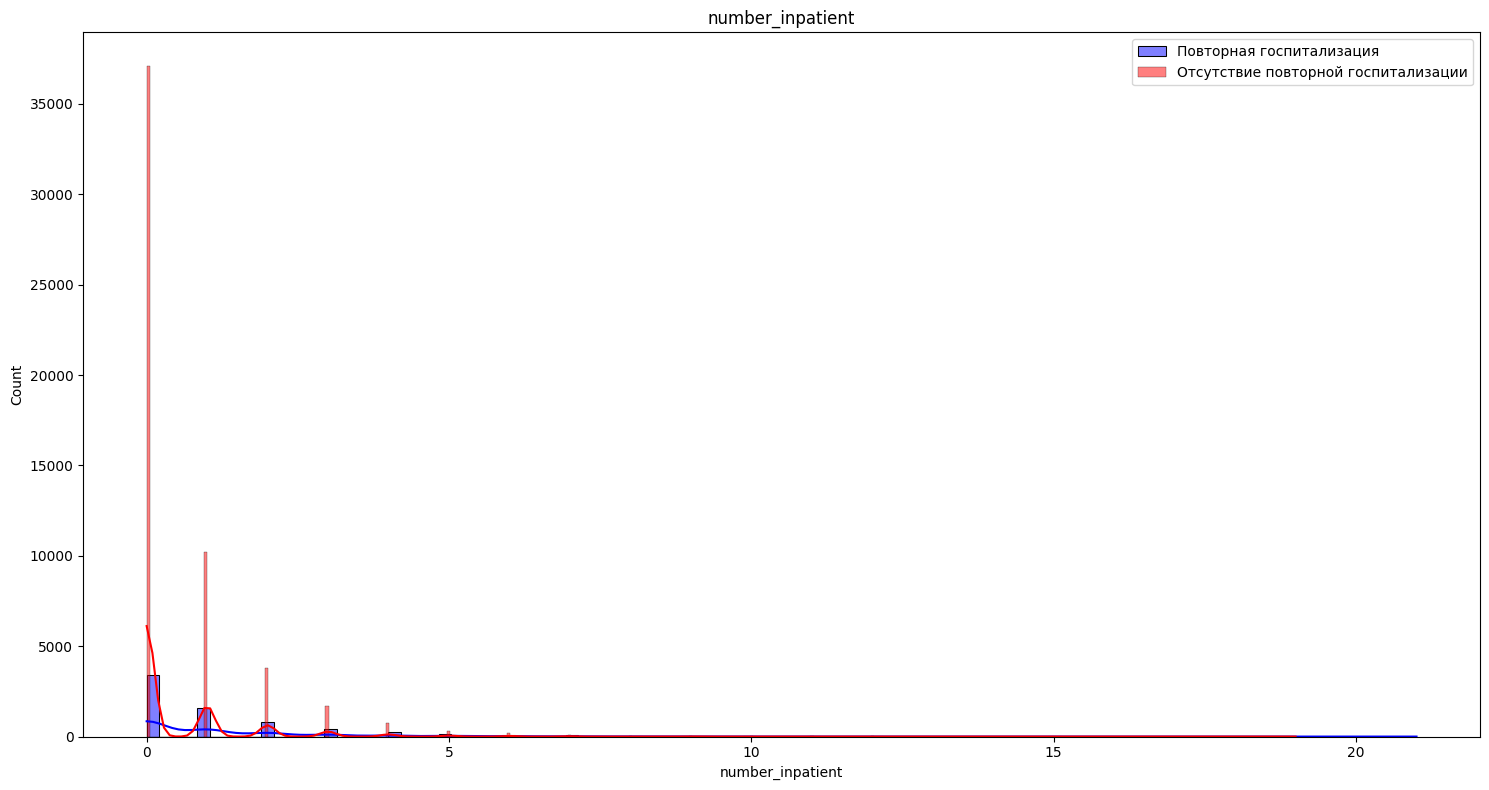

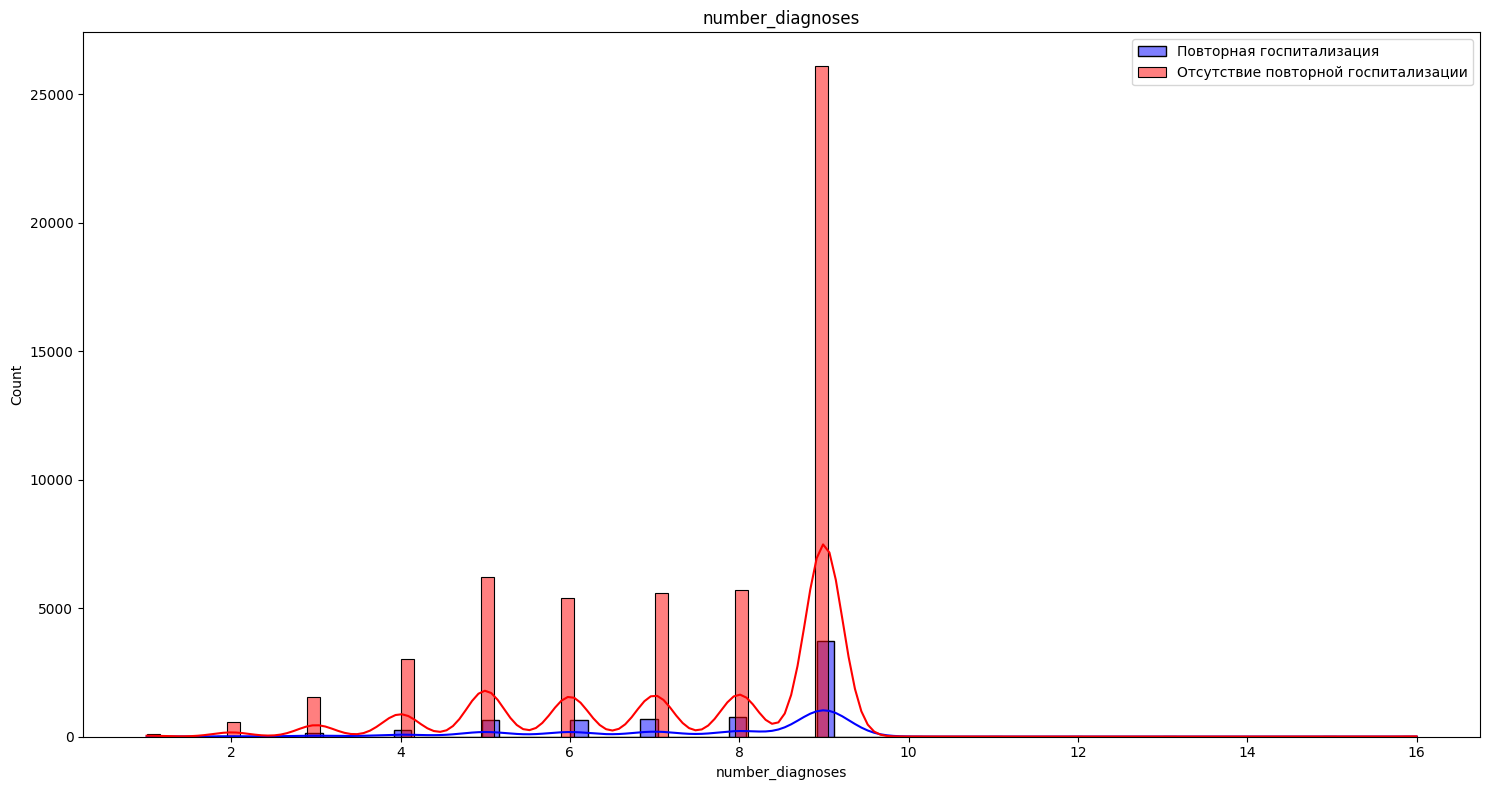

In [21]:
indx = 0
rows_num = 1

for j in range(1,12):
    fig, axes = plt.subplots(1, rows_num, figsize=(15, 8))
    # axes = axes.flatten()
    for i in range(rows_num):
        if indx >= len(numeric_column):
            break
        sns.histplot(
            data = df.iloc[train_idx][df.iloc[train_idx]['readmitted'] == 1],
            x = numeric_column[indx],
            color = 'blue',
            label = 'Повторная госпитализация',
            alpha = 0.5,
            kde = True,
            # ax=axes[i]
        )
        sns.histplot(
            data = df.iloc[train_idx][df.iloc[train_idx]['readmitted'] == 0],
            x = numeric_column[indx],
            color = 'red',
            label = 'Отсутствие повторной госпитализации',
            alpha = 0.5,
            kde = True,
            # ax=axes[i]
        )
        # axes[i].set_title(numeric_column[indx])
        # axes[i].legend()
        plt.title(numeric_column[indx])
        plt.legend()
        indx += 1
    plt.tight_layout()
    plt.show()


Основной вывод: хотя число повторных госпитализаций меньше общего числа пациентов, пропорционально синие и красные столбцы в целом повторяют друг друга. Это может говорить о том, что данные признаки, возможно, не являются сильными предикторами повторной госпитализации

#### 5. Удаление ненужных столбцов  

Для начала оценим важность препаратов, далее просмотрев количество пропусков, оценим, нужно ли оставлять или нет

| Препарат | Назначение / действие | Важность |
|-----------|------------------------|-----------|
| Metformin | Снижает выработку глюкозы, повышает чувствительность к инсулину | 4 |
| Insulin | Заместительная гормональная терапия при диабете | 4 |
| Glimepiride | Стимулирует секрецию инсулина (современная сульфонилмочевина) | 3 |
| Glipizide | Стимулирует выработку инсулина | 3 |
| Glyburide | Аналог glipizide, стимулирует поджелудочную | 3 |
| Pioglitazone | Повышает чувствительность тканей к инсулину | 3 |
| Repaglinide | Быстродействующий стимулятор инсулина (перед едой) | 2 |
| Nateglinide | Аналог repaglinide, короткое действие | 2 |
| Rosiglitazone | Повышает чувствительность к инсулину, ограничен по применению | 2 |
| Acarbose | Замедляет всасывание углеводов в кишечнике | 2 |
| Miglitol | Аналог acarbose | 2 |
| Glyburide-Metformin | Комбинированная терапия (стимулятор + сенситайзер) | 2 |
| Glipizide-Metformin | Комбинация аналогичного действия | 2 |
| Metformin-Pioglitazone | Комбинация сенситайзеров | 2 |
| Metformin-Rosiglitazone | Комбинация, ограниченное применение | 2 |
| Chlorpropamide | Старый стимулятор инсулина | 1 |
| Tolbutamide | Старое поколение сульфонилмочевин | 1 |
| Tolazamide | Устаревший препарат | 1 |
| Acetohexamide | Старый препарат сульфонилмочевины | 1 |
| Troglitazone | Снят с рынка (токсичен) | 1 |
| Examide | Не используется в клинике | 1 |
| Citoglipton | Отсутствует в практике | 1 |
| Glimepiride-Pioglitazone | Комбинация, не имеет преимуществ | 1 |


Удаляем следующие столбцы:
* 'encounter_id' - id посещения; 'patient_nbr' сохраняем только для группового разделения выборки и не включаем в признаки модели
* 'weight' - почти 97% пропусков(+ не несет в себе особо важной информации)
* 'examide','citoglipton','metformin-pioglitazone', 'metformin-rosiglitazone', 'glimepiride-pioglitazone', 'glipizide-metformin', 'troglitazone', 'acetohexamide', 'tolazamide', 'miglitol', 'tolbutamide', 'chlorpropamide', 'acarbose', 'glyburide-metformin', 'nateglinide' - по важности низкое значение, либо неиспользуемый в клинике, либо по балансу значений не подходит(очень много пропусков - неизвестных значений).

In [22]:
df.drop(['weight', 'examide', 'citoglipton','metformin-pioglitazone',
          'metformin-rosiglitazone', 'glimepiride-pioglitazone', 'glipizide-metformin',
            'troglitazone', 'tolazamide', 'acetohexamide','miglitol', 'tolbutamide', 'chlorpropamide',
              'acarbose', 'glyburide-metformin', 'nateglinide','encounter_id'
              ], axis=1, inplace=True)

In [23]:
df.shape

(101763, 33)

In [24]:
print(f'Список оставшихся колонок: {df.columns.to_list()}')

Список оставшихся колонок: ['patient_nbr', 'race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin', 'change', 'diabetesMed', 'readmitted']


#### 1: клинически значимые признаки  
В общем заболевания классифицируются по следующим принципам: характер заболевания(хроническое, острое заболевание), основная локализация болезни(система крови, органов дыхания, сердца и тд), по патогенезу(аутоиммунное, аллергическое и тд), по этиологии(генетическое, инфекционное и тд), возраст пациента,  основной принцип лечения(хирургическое вмешательство, терапевтическое лечение), по полу. Отталкиваясь от этих принципов можно классифицировать болезни и понять как тяжело лечится болезнь, может ли быть рецидив, как долго восстанавливается пациент.
    
Признаки, которые прямо или косвенно связаны с этими принципами: 'age', 'gender', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses','medical_specialty', 'change', 'diabetesMed', 'number_emergency' + все препараты и значение анализов  
    
Дополнительно проверяем признаки, описывающие госпитализацию и интенсивность лечения: 'time_in_hospital', 'payer_code', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_inpatient'  
    
Количественные признаки по предварительным графикам не являются сильными предикторами  
  
#### 2: перекосы в распределении
Правосторонний перекос: 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient'. Левосторонний перекос: 'number_diagnoses'.  
   
Признаки 'admission_type_id', 'discharge_disposition_id', 'admission_source_id' скорее являются категориальными, нежели числовыми, возможно стоит их преобразовать.
Признаки 'number_outpatient', 'number_emergency', 'number_inpatient'. Создать бинарный признак: было ли предыдущее посещение.  
    
Для 'time_in_hospital, 'num_procedures', 'num_medications' можно попробовать сделать логарифмирование.  
     
Перекос не всегда нужно исправлять, он может нести важную информацию для модели, стоит протестировать в разных модификациях.
   
#### 3: дисбаланс классов
Данные имеют сильный дисбаланс классов в целевой переменной. В данном случае разница в 8 раз. Я бы в первую очередь попробовала комбинирование андерсемплинга и оверсемплинга (например SMOTE + Tomek Links/Edited Nearest Neighbors). Поскольку медицинские данные очень сложны и вероятнее всего отдельный метод может оказаться неэффективным, при недостатке андерсемплинга потеря информации, при недостатке оверсемплинга переобучение и шум. Нам нужно увеличить количество редких примеров (SMOTE) и одновременно удалить шум, возникающий в результате перекрытия классов(Tomek Links: удаляет пары ближайших образцов, принадлежащих к разным классам).

## 2. Инженерия признаков

### 2.1. Обработка пропусков

In [25]:
del str_nan['weight']
print('Категориальные столбцы с пропусками:')
print(str_nan)

Категориальные столбцы с пропусками:
{'race': 2271, 'payer_code': 40255, 'medical_specialty': 49947, 'diag_1': 21, 'diag_2': 358, 'diag_3': 1423, 'max_glu_serum': 96417, 'A1Cresult': 84745}


#### Столбец "race"  

Для пропущенных значений создаём отдельную категорию `Missing`. Распределение по target ниже используется только как EDA на train.


In [26]:
df['race'] = df['race'].fillna('Missing')
df_train_eda = df.iloc[train_idx]
df_missing_race = df_train_eda[df_train_eda['race'] == 'Missing']
df_other = df_train_eda[df_train_eda['race'] == 'Other']


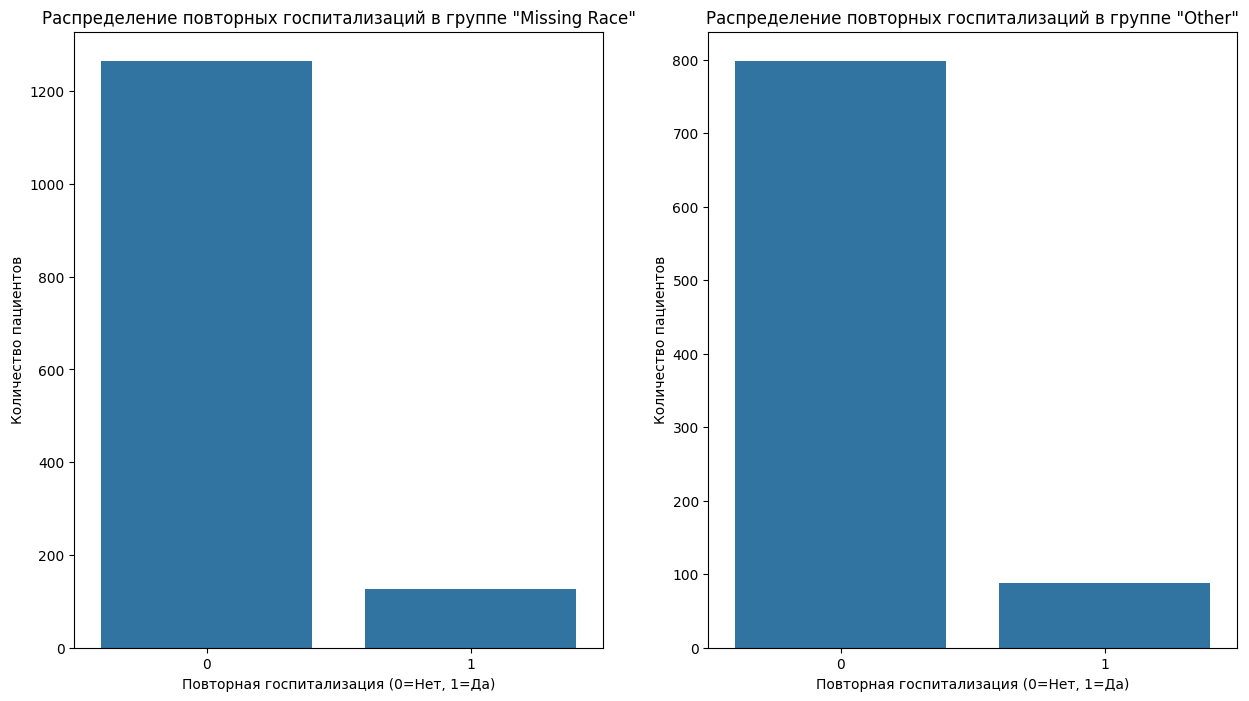

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

sns.countplot(
    data=df_missing_race,
    x='readmitted',
    ax=axes[0]
)

axes[0].set_title('Распределение повторных госпитализаций в группе "Missing Race"')
axes[0].set_xlabel('Повторная госпитализация (0=Нет, 1=Да)')
axes[0].set_ylabel('Количество пациентов')

sns.countplot(
    data=df_other,
    x='readmitted',
    ax=axes[1]
)

axes[1].set_title('Распределение повторных госпитализаций в группе "Other"')
axes[1].set_xlabel('Повторная госпитализация (0=Нет, 1=Да)')
axes[1].set_ylabel('Количество пациентов')
plt.show()

Категорию `Missing` оставляем отдельной и не объединяем с другими категориями по целевой переменной.


In [28]:
df['race'].unique()


array(['Caucasian', 'AfricanAmerican', 'Missing', 'Other', 'Asian',
       'Hispanic'], dtype=object)

#### Столбцы 'payer_code', 'medical_specialty', 'max_glu_serum', 'A1Cresult'

Для столбцов, где около половины и более пропусков, но которые содержат важную информацию, пропуски определим в отдельную категорию.

In [29]:
df['payer_code'] = df['payer_code'].fillna('Unknown')
df['medical_specialty'] = df['medical_specialty'].fillna('Unknown')
df['max_glu_serum'] = df['max_glu_serum'].fillna('Unknown')
df['A1Cresult'] = df['A1Cresult'].fillna('Unknown')


#### Столбцы 'diag_1', 'diag_2', 'diag_3'

Присутствуют пропуски по диагнозам. Это может быть важной информацией, возможно диагноз не удалось установить. Заменим в этих столбцах все пропуски на 10000 (условно обозначаем отдельную группу, записываем цифрами, чтобы потом обрабатывать числовые значения)

In [30]:
df['diag_1'] = df['diag_1'].fillna('10000')
df['diag_2'] = df['diag_2'].fillna('10000')
df['diag_3'] = df['diag_3'].fillna('10000')

#### Столбец 'gender'

В `gender` всего несколько пропусков; строки с ними удалены до разбиения выборки, без использования target.


In [31]:
print('Пропусков в gender:', df['gender'].isna().sum())


Пропусков в gender: 0


In [32]:
df = df.reset_index(drop=True)


#### Проверим пропуски:

In [33]:
for column in df:
    if df[column].isnull().sum() != 0:
        print(column, df[column].isnull().sum())

Для хорошей модели необходимо правильно преобразовать категориальные признаки.  
  
Чтобы это сделать нужно понять, какую информацию мы можем достать из столбца и насколько она важна. Например у нас есть столбец медицинская специальность, в которой 79 значений, которые в свою очередь надо сгруппировать. Есть значение 'кардиохирургия', но куда его отнести, к кардиологам или к хирургам? Кардиология классифицирует болезнь, а хирургия указывает на вид лечения. Поскольку у нас есть ещё столбик с диагнозом, то если отнести к кардиологии, то это будет повтор информации, а из столбика специальность мы можем достать новую информацию о виде лечения.

Таким образом первое предположение о кодировании

| Признак             | Уникальные значения | Кодирование |
|----------------------|---------------------|-------------|
| race                 | 5                   | one-hot |
| gender               | 2                   | бинарное |
| age                  | -                   | числовой признак |
| payer_code           | 17                  | one-hot |
| medical_specialty    | 73                  | группировка по виду лечения → one-hot |
| diag_1               | 717                 | группировка по области → one-hot |
| diag_2               | -                   | аналогично diag_1 → one-hot |
| diag_3               | -                   | аналогично diag_1 → one-hot |
| max_glu_serum        | 4                   | one-hot |
| A1Cresult            | 4                   | one-hot |
| metformin            | 4                   | порядковое кодирование |
| repaglinide          | 4                   | порядковое кодирование |
| glimepiride          | 4                   | порядковое кодирование |
| glipizide            | 4                   | порядковое кодирование |
| glyburide            | 4                   | порядковое кодирование |
| pioglitazone         | 4                   | порядковое кодирование |
| rosiglitazone        | 4                   | порядковое кодирование |
| insulin              | 4                   | порядковое кодирование |
| change               | 2                   | бинарное |
| diabetesMed          | 2                   | бинарное |


### 2.2. One-hot кодирование категориальных признаков и/или группировка редких категорий
### +
### 2.5. Кодировка клинической направленности диагнозов

In [34]:
numeric_column = []
object_column = []

for column in df:
    if is_object_dtype(df[column].dtype):
        object_column.append(column)
    else:
        numeric_column.append(column)

print('-'*60)
print(f'Категориальные признаки: \n{object_column} \nКоличество столбцов:{len(object_column)}')
print('-'*60)
print(f'Количественные признаки: \n{numeric_column} \nКоличество столбцов:{len(numeric_column)}')
print('-'*60)

------------------------------------------------------------
Категориальные признаки: 
['race', 'gender', 'age', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin', 'change', 'diabetesMed'] 
Количество столбцов:20
------------------------------------------------------------
Количественные признаки: 
['patient_nbr', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'readmitted'] 
Количество столбцов:13
------------------------------------------------------------


Обработка 'race'

In [35]:
encoder_race = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder_race.fit(df.iloc[train_idx][['race']])
encoded_array = encoder_race.transform(df[['race']])
encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoder_race.get_feature_names_out(['race']),
    index=df.index
)

df = pd.concat([df.drop(columns=['race']), encoded_df], axis=1)
race_cols = encoded_df.columns.tolist()


Обработка 'diag_1', 'diag_2', 'diag_3'

In [36]:
def diabetes(icd):
    try:
        return str(icd).startswith("250")
    except:
        return False

def hypertension(icd):
    try:
        code = float(icd)
        return 401 <= code <= 405
    except:
        return False

def infection(icd):
    try:
        code = float(icd)
        return 1 <= code <= 139
    except:
        return False

df['diabetes_flag'] = df[['diag_1','diag_2','diag_3']].apply(
    lambda x: any(diabetes(i) for i in x), axis=1
).astype(int)

df['hypertension_flag'] = df[['diag_1','diag_2','diag_3']].apply(
    lambda x: any(hypertension(i) for i in x), axis=1
).astype(int)

df['infection_flag'] = df[['diag_1','diag_2','diag_3']].apply(
    lambda x: any(infection(i) for i in x), axis=1
).astype(int)


In [37]:
def chronic(icd):
    if pd.isna(icd):
        return 0
    try:
        code = float(str(icd))
    except ValueError:
        return 0
    if 240 <= code <= 279:
        return 1
    elif 390 <= code <= 459:
        return 1
    elif 490 <= code <= 496:
        return 1
    elif 290 <= code <= 319:
        return 1
    elif 330 <= code <= 349:
        return 1
    elif 580 <= code <= 629:
        return 1
    elif 710 <= code <= 739:
        return 1
    elif 140 <= code <= 239:
        return 1

    else:
        return 0

df['n_chronic_conditions'] = df[['diag_1', 'diag_2', 'diag_3']].apply(
    lambda x: sum(chronic(i) for i in x), axis=1
)


Для начала заменим E и V (внешние причины травм и дополнительная классификация) на числовые значения, далее сгруппируем диагнозы по мкб-9.

In [38]:
cols = ['diag_1', 'diag_2', 'diag_3']

for i in cols:
    df.loc[df[i].str.contains('E'),i] = '1000'
    df.loc[df[i].str.contains('V'),i] = '1001'

df = df.astype({'diag_1': float, 'diag_2': float, 'diag_3': float})

In [39]:
df['diag_1'].dtypes

dtype('float64')

In [40]:
for i in cols:

    df[i] = df[i].astype('string')

    numeric = pd.to_numeric(df[i], errors='coerce')

    df.loc[(1 <= numeric) & (numeric <= 139), i] = 'Infectious'
    df.loc[(140 <= numeric) & (numeric <= 239), i] = 'Neoplasms'
    df.loc[(240 <= numeric) & (numeric <= 279), i] = 'Endocrine/metabolic'
    df.loc[(280 <= numeric) & (numeric <= 289), i] = 'Blood disorders'
    df.loc[(290 <= numeric) & (numeric <= 319), i] = 'Mental disorders'
    df.loc[(320 <= numeric) & (numeric <= 389), i] = 'Nervous system'
    df.loc[(390 <= numeric) & (numeric <= 459), i] = 'Circulatory system'
    df.loc[(460 <= numeric) & (numeric <= 519), i] = 'Respiratory system'
    df.loc[(520 <= numeric) & (numeric <= 579), i] = 'Digestive system'
    df.loc[(580 <= numeric) & (numeric <= 629), i] = 'Genitourinary system'
    df.loc[(630 <= numeric) & (numeric <= 679), i] = 'Pregnancy'
    df.loc[(680 <= numeric) & (numeric <= 709), i] = 'Skin'
    df.loc[(710 <= numeric) & (numeric <= 739), i] = 'Musculoskeletal'
    df.loc[(740 <= numeric) & (numeric <= 759), i] = 'Congenital anomalies'
    df.loc[(760 <= numeric) & (numeric <= 779), i] = 'Perinatal conditions'
    df.loc[(780 <= numeric) & (numeric <= 799), i] = 'Symptoms/ill-defined'
    df.loc[(800 <= numeric) & (numeric <= 999), i] = 'Injury/poisoning'
    df.loc[numeric == 1000, i] = 'External causes'
    df.loc[numeric == 1001, i] = 'Supplementary'
    df.loc[numeric == 10000, i] = 'Unknown'


In [41]:
diag_cols = ['diag_1', 'diag_2', 'diag_3']

encoder_pipeline = Pipeline([
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

encoder_pipeline.fit(df.iloc[train_idx][diag_cols])
encoded_array = encoder_pipeline.transform(df[diag_cols])

encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoder_pipeline.named_steps['onehot'].get_feature_names_out(diag_cols),
    index=df.index
)

df = pd.concat([df.drop(columns=diag_cols), encoded_df], axis=1)


Обработка 'medical_specialty'

In [42]:
def map_specialty_to_group(specialty):

    # if pd.isna(specialty):
    #     return "Unknown"

    s = str(specialty).strip()
    if s == 'Unknown':
        return 'Unknown'
    if s.startswith("Surgery") or s in ["Surgeon", "SurgicalSpecialty"]:
        return "Surgery"
    elif "Cardiology" in s:
        return "Cardiology"
    elif "Endocrinology" in s or "Metabolism" in s:
        return "Endocrinology"
    elif "Gastroenterology" in s or "Proctology" in s or "Colon" in s:
        return "Gastroenterology"
    elif "Nephrology" in s:
        return "Nephrology"
    elif "Pulmonology" in s:
        return "Pulmonology"
    elif "Hematology" in s or "Oncology" in s:
        return "Oncology/Hematology"
    elif "Neurology" in s or "Neurophysiology" in s:
        return "Neurology"
    elif "Psychiatry" in s or "Psychology" in s:
        return "Psychiatry/Psychology"
    elif "Gynecology" in s or "Obstetrics" in s or "Perinatology" in s:
        return "Ob/Gyn"
    elif "Dermatology" in s:
        return "Dermatology"
    elif "Orthopedics" in s or "Sports" in s:
        return "Orthopedics/Sports"
    elif "Otolaryngology" in s or "Ophthalmology" in s:
        return "ENT/Ophthalmology"
    elif "Allergy" in s or "Immunology" in s:
        return "Allergy/Immunology"
    elif "Infectious" in s:
        return "InfectiousDiseases"
    elif "Anesthesiology" in s:
        return "Anesthesiology"
    elif "Radiology" in s or "Radiologist" in s or "Pathology" in s:
        return "Radiology/Pathology"
    elif "Rehabilitation" in s:
        return "Rehabilitation"
    elif "Rheumatology" in s:
        return "Rheumatology"
    elif "Dentistry" in s:
        return "Dentistry"
    elif "Podiatry" in s:
        return "Podiatry"
    elif "Speech" in s:
        return "Speech"
    elif any(x in s for x in ["Internal", "Family", "GeneralPractice", "Osteopath", "Hospitalist"]):
        return "InternalMedicine"
    elif s in ["OutreachServices", "DCPTEAM", "Resident", "PhysicianNotFound"]:
        return "Other"
    else:
        return "Other"


In [43]:

df['specialty_group'] = df['medical_specialty'].apply(map_specialty_to_group)
df['specialty_group'].unique()

array(['Endocrinology', 'Unknown', 'InternalMedicine', 'Cardiology',
       'Surgery', 'Orthopedics/Sports', 'Gastroenterology', 'Nephrology',
       'Psychiatry/Psychology', 'Other', 'Pulmonology', 'Ob/Gyn',
       'Oncology/Hematology', 'ENT/Ophthalmology', 'Neurology',
       'Anesthesiology', 'Radiology/Pathology', 'Podiatry',
       'Rehabilitation', 'InfectiousDiseases', 'Rheumatology',
       'Allergy/Immunology', 'Dentistry', 'Dermatology', 'Speech'],
      dtype=object)

In [44]:
df.drop(['medical_specialty'], axis=1, inplace=True)

In [45]:
encoder_specialty = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder_specialty.fit(df.iloc[train_idx][['specialty_group']])
encoded_array = encoder_specialty.transform(df[['specialty_group']])
encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoder_specialty.get_feature_names_out(['specialty_group']),
    index=df.index
)

df = pd.concat([df.drop(columns=['specialty_group']), encoded_df], axis=1)
specialty_cols = encoded_df.columns.tolist()


### 2.4. Конвертация диапазонов категорий в числовые группы

In [46]:
age_map = {'[0-10)': 5, '[10-20)': 15, '[20-30)':25, '[30-40)': 35, '[40-50)': 45, '[50-60)': 55, '[60-70)': 65,
 '[70-80)': 75, '[80-90)': 85, '[90-100)' :95 }
df['age'] = df['age'].map(age_map)

In [47]:
df.dropna(subset=['gender'], inplace = True)
drug = ['metformin', 'repaglinide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin']
dosage = ['No', 'Down', 'Steady', 'Up']

encoder_drug = OrdinalEncoder(categories = [dosage])

for i in drug:
    df[i] = encoder_drug.fit_transform(df[[i]])


In [48]:
lab_cols_raw = ['max_glu_serum', 'A1Cresult']
encoder_labs = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder_labs.fit(df.iloc[train_idx][lab_cols_raw])
encoded_array = encoder_labs.transform(df[lab_cols_raw])
encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoder_labs.get_feature_names_out(lab_cols_raw),
    index=df.index
)

df = pd.concat([df.drop(columns=lab_cols_raw), encoded_df], axis=1)
lab_cols = encoded_df.columns.tolist()


Обработка `payer_code` как номинального категориального признака.


In [49]:
encoder_payer = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder_payer.fit(df.iloc[train_idx][['payer_code']])
encoded_array = encoder_payer.transform(df[['payer_code']])
encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoder_payer.get_feature_names_out(['payer_code']),
    index=df.index
)

df = pd.concat([df.drop(columns=['payer_code']), encoded_df], axis=1)
payer_cols = encoded_df.columns.tolist()


### 2.6. Создание бинарных признаков: 'gender', 'change', 'diabetesMed'

In [50]:
gender_map = {'Male': 0, 'Female': 1}
df['gender'] = df['gender'].map(gender_map)

change_map = {'No': 0, 'Ch': 1}
df['change'] = df['change'].map(change_map)

diabetesmed_map = {'No': 0, 'Yes': 1}
df['diabetesMed'] = df['diabetesMed'].map(diabetesmed_map)

### 2.3. Смысловые группы признаков. Агрегированные признаки

In [51]:
print(f'Список всех колонок: {df.columns.to_list()}')

Список всех колонок: ['patient_nbr', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'metformin', 'repaglinide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin', 'change', 'diabetesMed', 'readmitted', 'race_AfricanAmerican', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Missing', 'race_Other', 'diabetes_flag', 'hypertension_flag', 'infection_flag', 'n_chronic_conditions', 'diag_1_Blood disorders', 'diag_1_Circulatory system', 'diag_1_Congenital anomalies', 'diag_1_Digestive system', 'diag_1_Endocrine/metabolic', 'diag_1_Genitourinary system', 'diag_1_Infectious', 'diag_1_Injury/poisoning', 'diag_1_Mental disorders', 'diag_1_Musculoskeletal', 'diag_1_Neoplasms', 'diag_1_Nervous system', 'diag_1_Pregnancy', 'diag_1_Respiratory system', 'diag_1_Sk

#### Группировка признаков - лекарства

In [52]:
df_drug = pd.DataFrame()
for i in drug:
    df_drug[i] = df[i]

In [53]:
df_drug

,metformin,repaglinide,glimepiride,glipizide,glyburide,pioglitazone,rosiglitazone,insulin
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
2,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
4,0.0,0.0,0.0,2.0,0.0,0.0,0.0,2.0
...,...,...,...,...,...,...,...,...
101758,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
101759,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
101760,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
101761,0.0,0.0,0.0,2.0,0.0,2.0,0.0,3.0


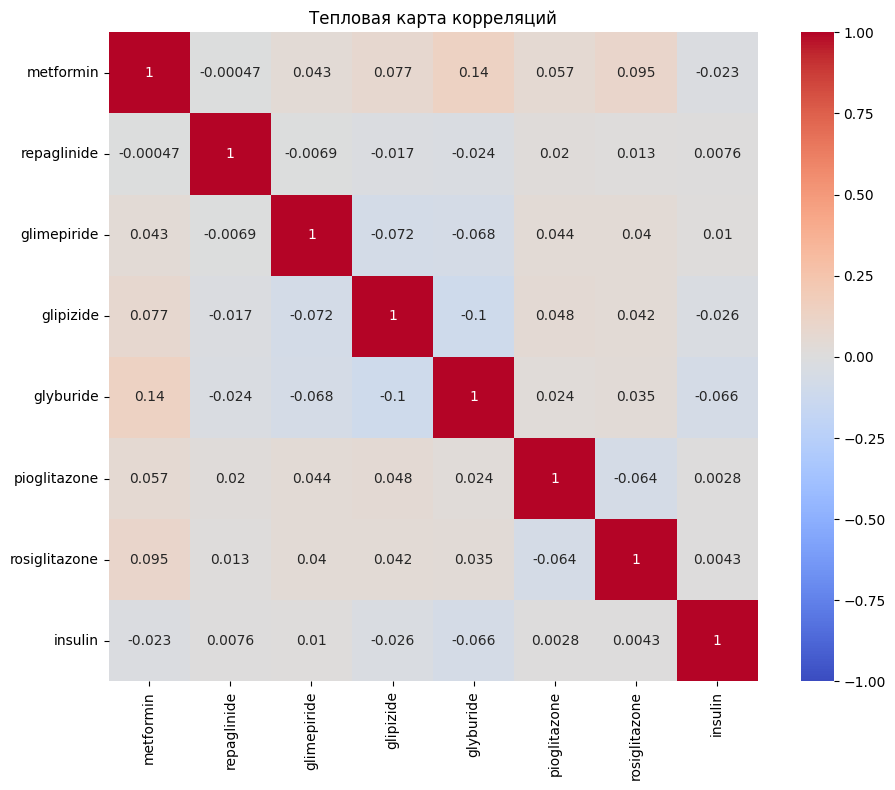

In [54]:
corr_matrix_drug = df_drug.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_drug,
annot=True,
cmap='coolwarm',
vmin=-1, vmax=1,

square=True) #
plt.title('Тепловая карта корреляций')
plt.tight_layout()
plt.show()

По карте корреляций лекарства не коррелируют друг с другом, следовательно каждый столбик несет в себе уникальную информацию, можно создать агрегированный столбик и посмотреть как он влияет на качество модели, но удалять исходные не нужно.

In [55]:
df['drug_intensity'] = df_drug.sum(axis=1)


Группировка признаков - активность лечения

In [56]:
df_activ = df[['num_lab_procedures', 'num_procedures','num_medications','number_diagnoses']]

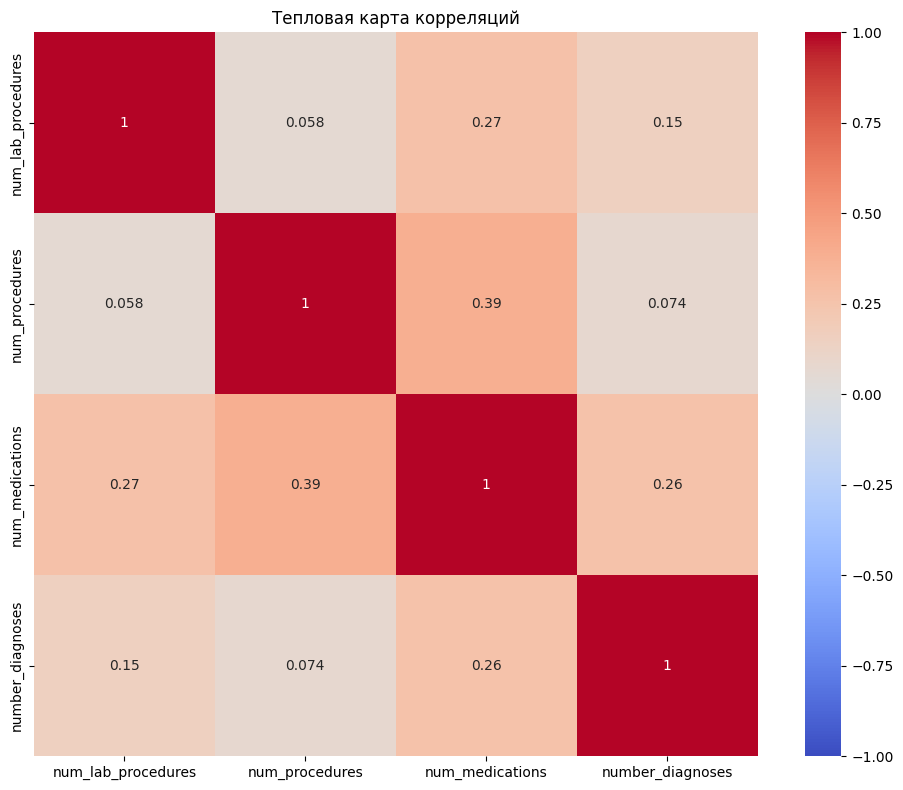

In [57]:
corr_matrix_activ = df_activ.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_activ,
annot=True,
cmap='coolwarm',
vmin=-1, vmax=1,
square=True) #
plt.title('Тепловая карта корреляций')
plt.tight_layout()
plt.show()

Корреляции слабые, следовательно каждый столбик содержит уникальную информацию

In [58]:
df['activity'] = df_activ.sum(axis=1)

Группировка признаков - визиты

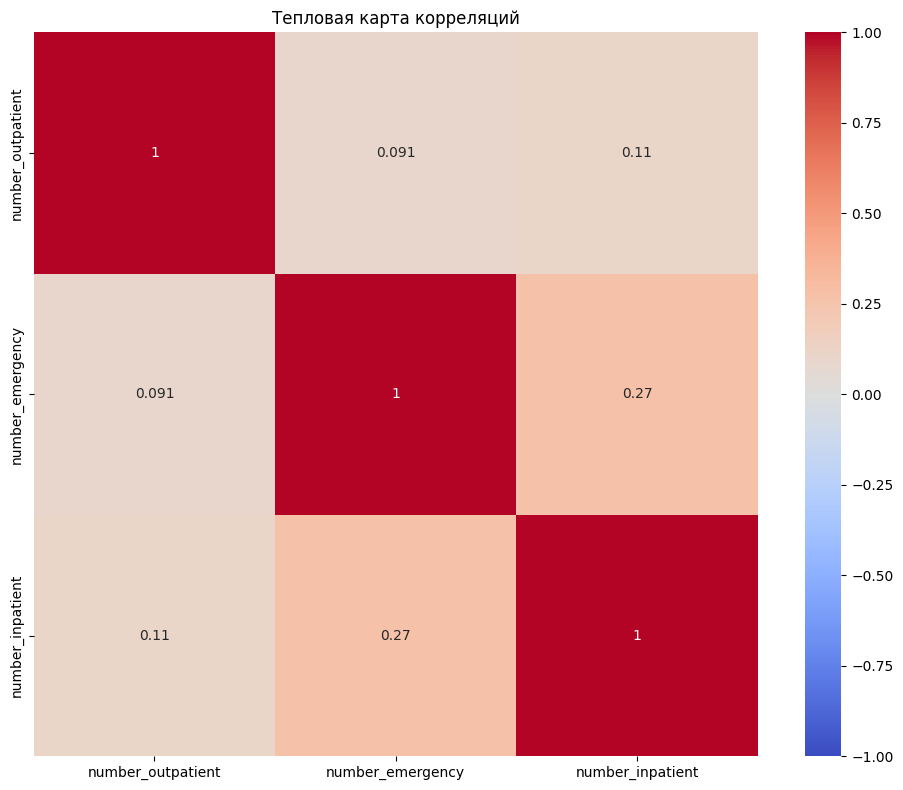

In [59]:
df_visits = df[['number_outpatient', 'number_emergency', 'number_inpatient']]

corr_matrix_visits = df_visits.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_visits,
annot=True,
cmap='coolwarm',
vmin=-1, vmax=1,
square=True) #
plt.title('Тепловая карта корреляций')
plt.tight_layout()
plt.show()

Корреляции слабые, следовательно каждый столбик содержит уникальную информацию

In [60]:
df['total_visits'] = df_visits.sum(axis=1)

Группировка признаков - индикаторы исхода, источника и типа госпитализации

In [61]:
df_adm =df[['admission_type_id', 'discharge_disposition_id', 'admission_source_id']]

Объединим редкие группы в одну

In [62]:
for i in df_adm:
    print(df[i].value_counts())


admission_type_id
1    53988
3    18868
2    18480
6     5291
5     4785
8      320
7       21
4       10
Name: count, dtype: int64
discharge_disposition_id
1     60232
3     13954
6     12902
18     3691
2      2128
22     1992
11     1642
5      1184
25      989
4       815
7       623
23      412
13      399
14      372
28      139
8       108
15       63
24       48
9        21
17       14
16       11
19        8
10        6
27        5
12        3
20        2
Name: count, dtype: int64
admission_source_id
7     57492
1     29564
17     6781
4      3187
6      2264
2      1104
5       855
3       187
20      161
9       125
8        16
22       12
10        8
14        2
11        2
25        2
13        1
Name: count, dtype: int64


In [63]:
for i in df_adm:
    cat5 = df.iloc[train_idx][i].value_counts(normalize=True)
    categories = cat5[cat5 < 0.06].index
    print(categories)

    df[i] = df[i].apply(
        lambda x: 0 if x in categories else x
    )


Index([6, 5, 8, 7, 4], dtype='int64', name='admission_type_id')
Index([18,  2, 22, 11,  5, 25,  4,  7, 13, 23, 14, 28,  8, 15, 24,  9, 17, 16,
       12, 10, 19, 20, 27],
      dtype='int64', name='discharge_disposition_id')
Index([4, 6, 2, 5, 3, 20, 9, 8, 22, 10, 14, 11, 25], dtype='int64', name='admission_source_id')


In [64]:
df_adm =df[['admission_type_id', 'discharge_disposition_id', 'admission_source_id']]

Группировка признаков - демография

In [65]:
print(f'Список всех колонок: {df.columns.to_list()}')

Список всех колонок: ['patient_nbr', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'metformin', 'repaglinide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin', 'change', 'diabetesMed', 'readmitted', 'race_AfricanAmerican', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Missing', 'race_Other', 'diabetes_flag', 'hypertension_flag', 'infection_flag', 'n_chronic_conditions', 'diag_1_Blood disorders', 'diag_1_Circulatory system', 'diag_1_Congenital anomalies', 'diag_1_Digestive system', 'diag_1_Endocrine/metabolic', 'diag_1_Genitourinary system', 'diag_1_Infectious', 'diag_1_Injury/poisoning', 'diag_1_Mental disorders', 'diag_1_Musculoskeletal', 'diag_1_Neoplasms', 'diag_1_Nervous system', 'diag_1_Pregnancy', 'diag_1_Respiratory system', 'diag_1_Sk

In [66]:
df_demograp = df[['gender', *race_cols, 'age', *payer_cols]]


Группировка признаков - диагноз

In [67]:
diag_feature_cols = [
    c for c in df.columns
    if c.startswith('diag_1_') or c.startswith('diag_2_') or c.startswith('diag_3_')
]
df_diag = df[diag_feature_cols]


Группировка признаков - мед. специальность

In [68]:
df_med = df[specialty_cols]


Группировка признаков - анализы

In [69]:
df_an = df[lab_cols]


Группировка признаков - агрегирующие

In [70]:
df_agreg = df[['total_visits', 'drug_intensity', 'activity']]

### 2.7. Преобразование признаков в бинарные индикаторы

In [71]:
df['time_in_hospital'].value_counts()

df['long_stay'] = (df['time_in_hospital'] > 7).astype(int)

In [72]:
df['drug_intensity'].value_counts()

df['long_drug_intensity'] = (df['drug_intensity'] > 5).astype(int)

In [73]:
df['total_visits'].value_counts()

df['long_total_visits'] = (df['total_visits'] > 6).astype(int)

In [74]:
df_binar = df[['long_stay', 'long_drug_intensity', 'long_total_visits']]

### 2.8. Взаимодействие между признаками

Основные гипотезы:  
* Частота госпитализаций зависит от возраста
* Гендерные различия в течение диабета
* Долгое пребывание и частота процедур - тяжелое состояние
* Инфекция и долгое пребывание - слабый организм, возможны осложнения

In [75]:
df['age_num_inpatient'] = df['age'] * df['number_inpatient']
df['gender_diabetes'] = df['gender'] * df['diabetesMed'].astype(int)
df['longstay_procedures'] = df['long_stay'] * df['num_procedures']
df['infection_time'] = df['infection_flag'] * df['time_in_hospital']

In [76]:
df_interaction = df[['age_num_inpatient', 'gender_diabetes', 'longstay_procedures', 'infection_time']]

Группировка оставшихся признаков

In [77]:
df_other = df[['diabetesMed', 'change']]
df_flag = df[['hypertension_flag', 'infection_flag', 'n_chronic_conditions',]]

In [78]:
for i in df_flag:
    print(df[i].unique())

[0 1]
[0 1]
[1 3 2 0]


In [79]:
df.drop(['diabetes_flag'], axis=1, inplace=True)

In [80]:
df.columns.to_list()

['patient_nbr',
 'gender',
 'age',
 'admission_type_id',
 'discharge_disposition_id',
 'admission_source_id',
 'time_in_hospital',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'number_diagnoses',
 'metformin',
 'repaglinide',
 'glimepiride',
 'glipizide',
 'glyburide',
 'pioglitazone',
 'rosiglitazone',
 'insulin',
 'change',
 'diabetesMed',
 'readmitted',
 'race_AfricanAmerican',
 'race_Asian',
 'race_Caucasian',
 'race_Hispanic',
 'race_Missing',
 'race_Other',
 'hypertension_flag',
 'infection_flag',
 'n_chronic_conditions',
 'diag_1_Blood disorders',
 'diag_1_Circulatory system',
 'diag_1_Congenital anomalies',
 'diag_1_Digestive system',
 'diag_1_Endocrine/metabolic',
 'diag_1_Genitourinary system',
 'diag_1_Infectious',
 'diag_1_Injury/poisoning',
 'diag_1_Mental disorders',
 'diag_1_Musculoskeletal',
 'diag_1_Neoplasms',
 'diag_1_Nervous system',
 'diag_1_Pregnancy',
 'diag_1_Respiratory system',
 

In [81]:
df.shape

(101763, 150)

### 2.9 Масштабирование количественных признаков

1.  Группы, которые будут в каждом собранном датасете:  
Демография - df_demograp    
Диагнозы - df_diag    
Мед. спец - df_med    
diabetesMed/изменения - df_other  
Индикатор исхода/тип госпитализации - df_adm    
Анализы - df_an  
df['long_stay']  
    
2.  Группы с агрегацией(здесь мы выбираем, либо исходные столбцы, либо агрегирующие, либо всё вместе):  
Лекарства - df_drug  
Активность лечения - df_activ  
Кол-во визитов - df_visits  
  
или все это в агрегирующем состоянии df_agreg  

3.  Бинарные признаки(не используем вместе с агрегирующими df_binar)  
Важные заболевания - df_flag  
Время в госпитале/кол-во лекарств/кол-во визитов - df_binar (минус df['long_stay'] из основы, поскольку в бинар повтор)  

4.  Взаимодействие(обычно только для линейных моделей):  
df_interaction   

In [82]:
df1 = pd.concat([
    df_demograp, df_diag, df_med, df_other, df_adm, df_an,
    df[['long_stay']], df_drug, df_activ, df_visits, df_flag
], axis=1)

df2 = pd.concat([
    df_demograp, df_diag, df_med, df_other, df_adm, df_an,
    df[['long_stay']], df_drug, df_activ, df_visits, df_flag, df_agreg
], axis=1)

df3 = pd.concat([
    df_demograp, df_diag, df_med, df_other, df_adm, df_an,
    df[['long_stay']], df_flag, df_agreg
], axis=1)

df4 = pd.concat([
    df_demograp, df_diag, df_med, df_other, df_adm, df_an, df_flag, df_binar
], axis=1)

df5 = pd.concat([
    df4, df_interaction
], axis=1)

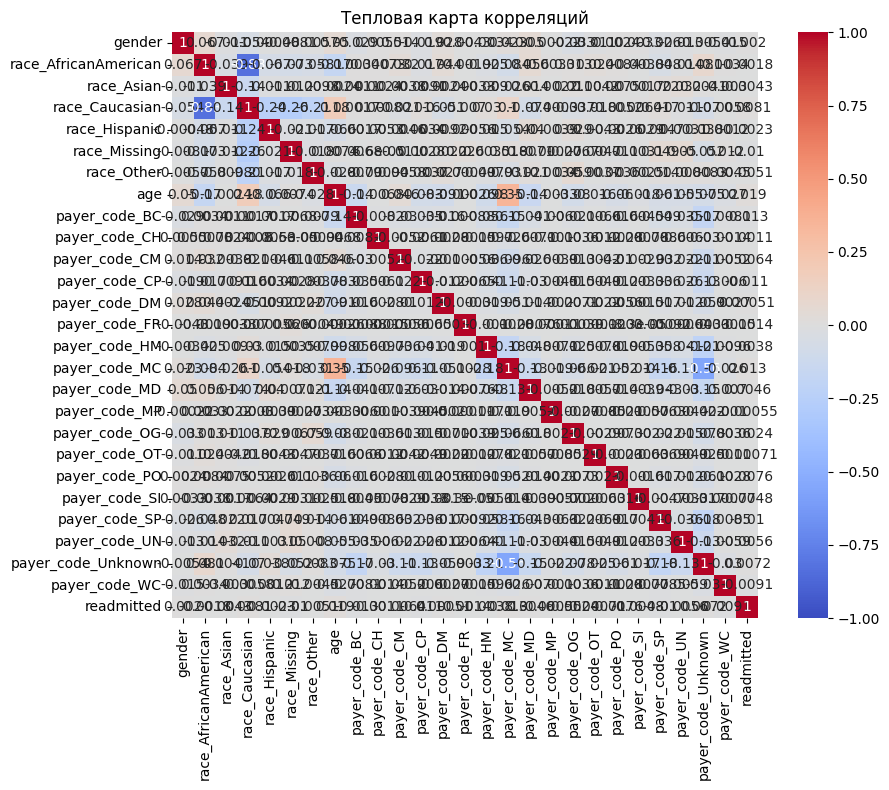

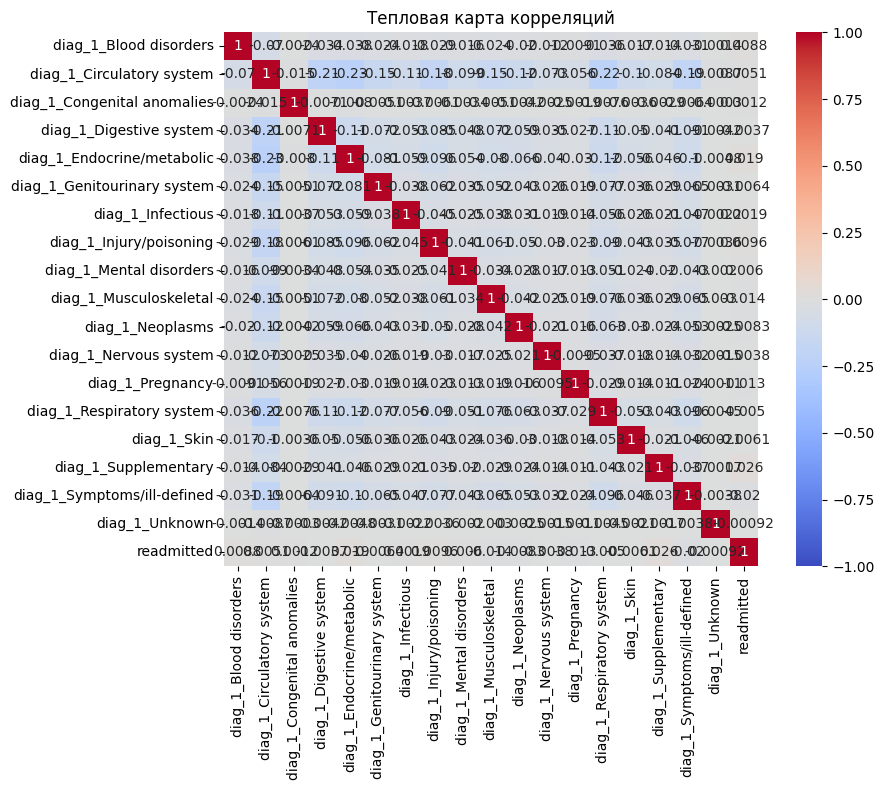

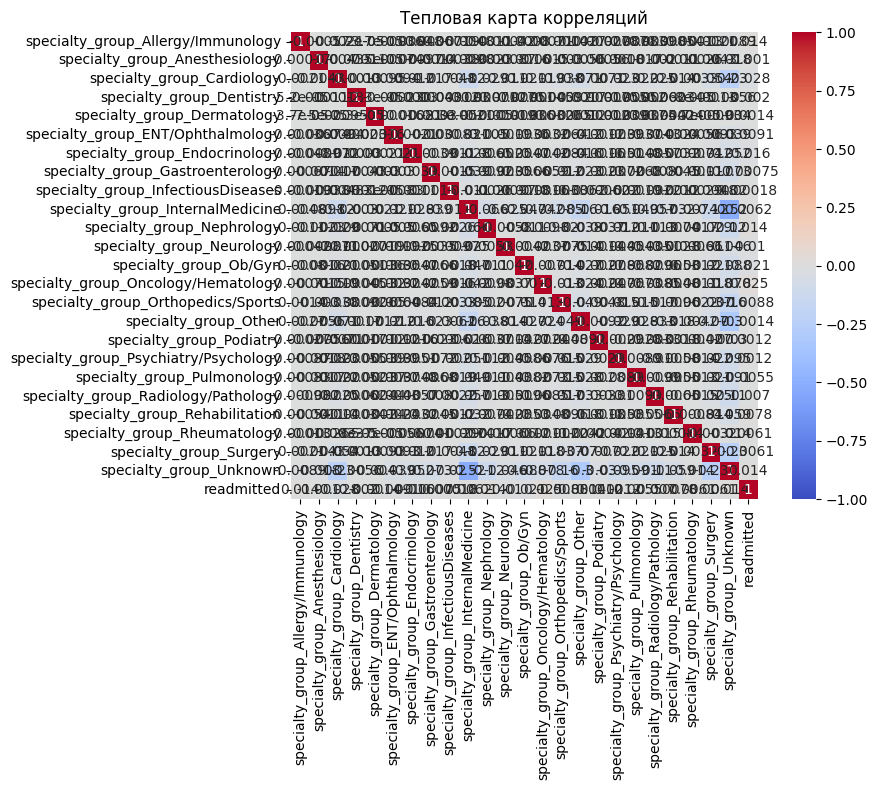

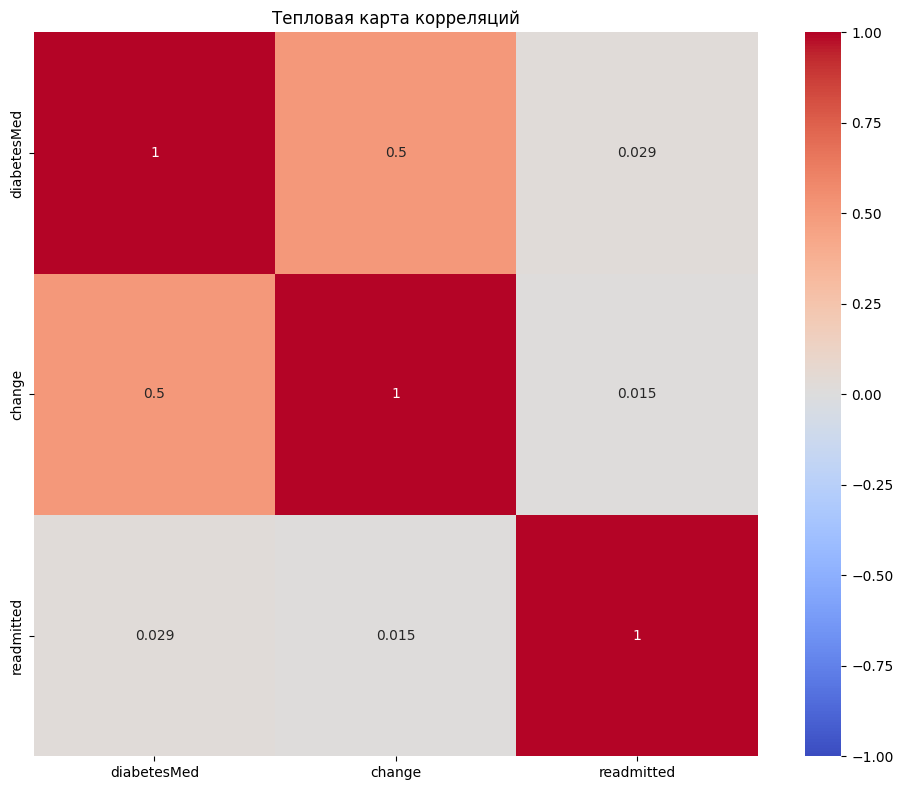

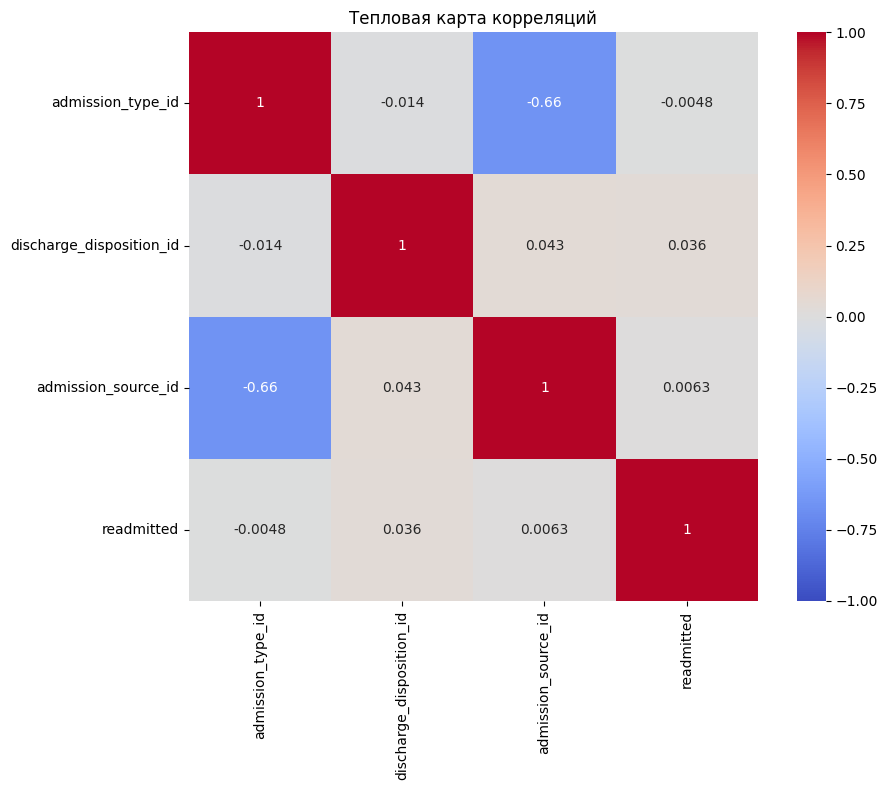

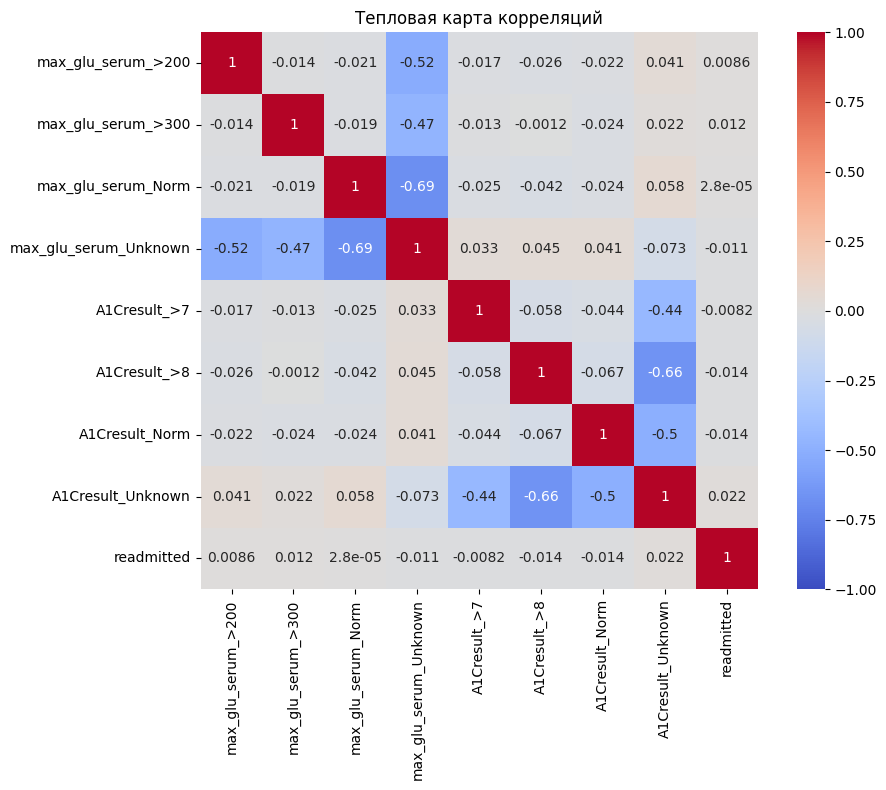

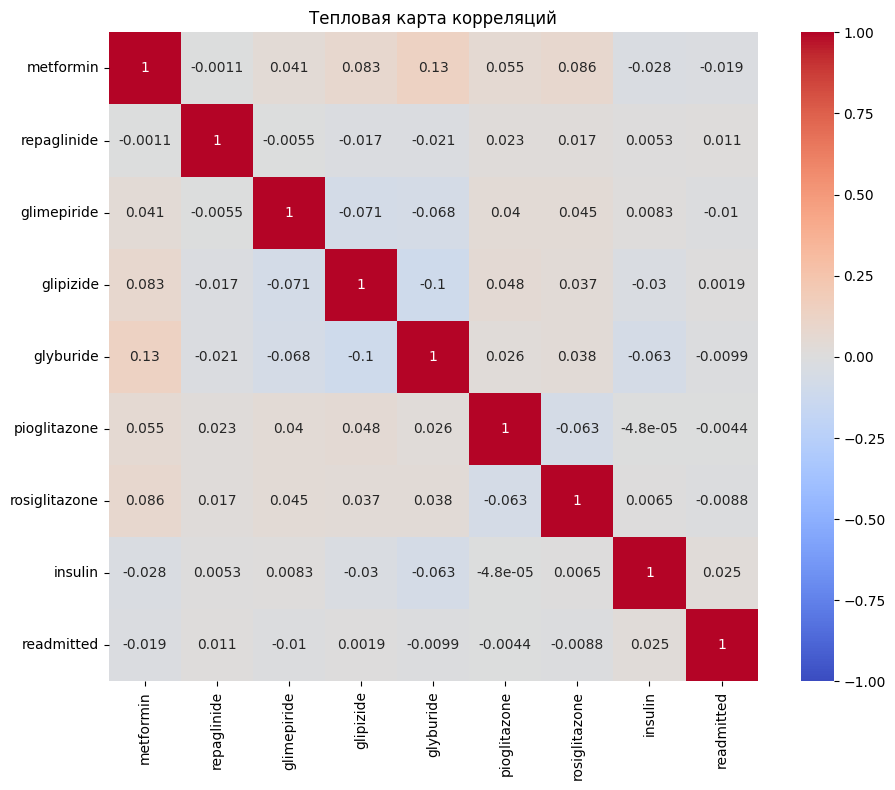

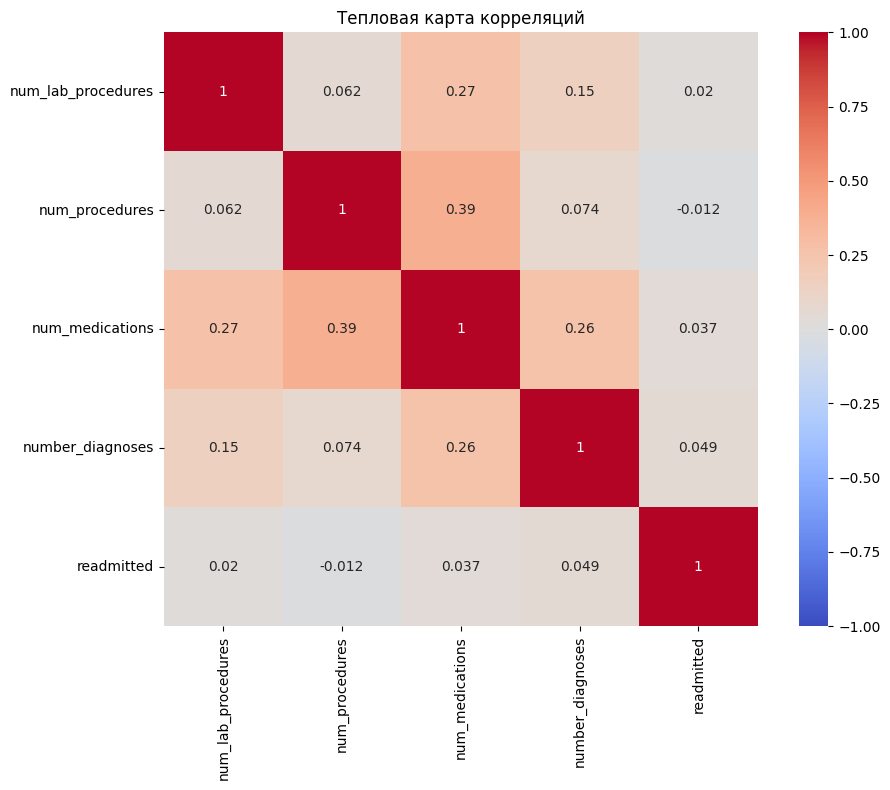

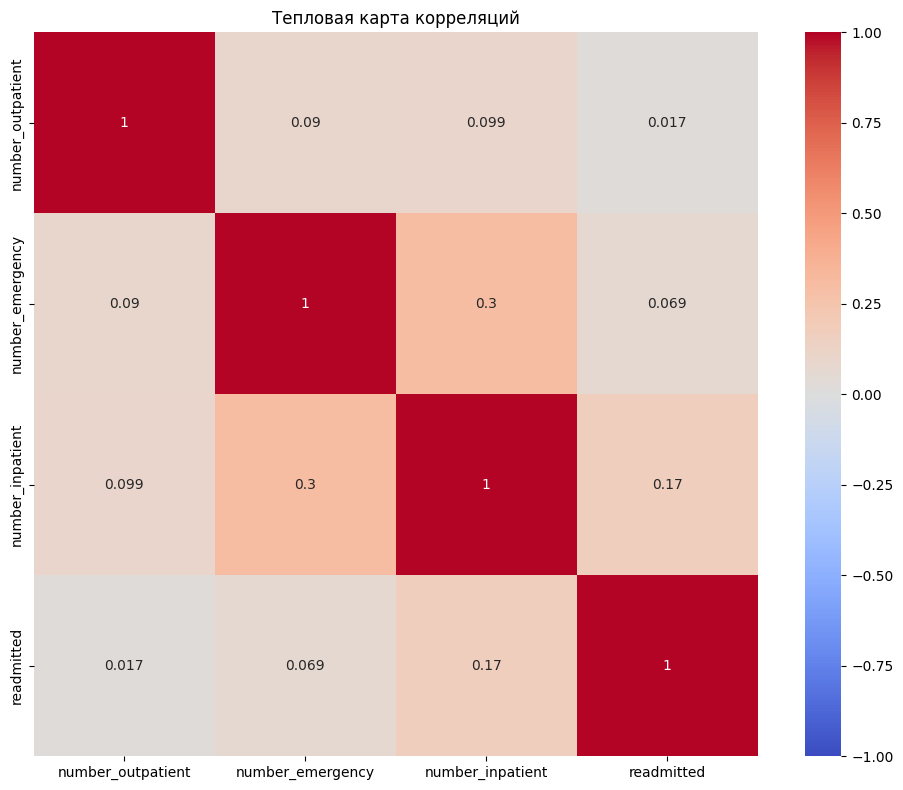

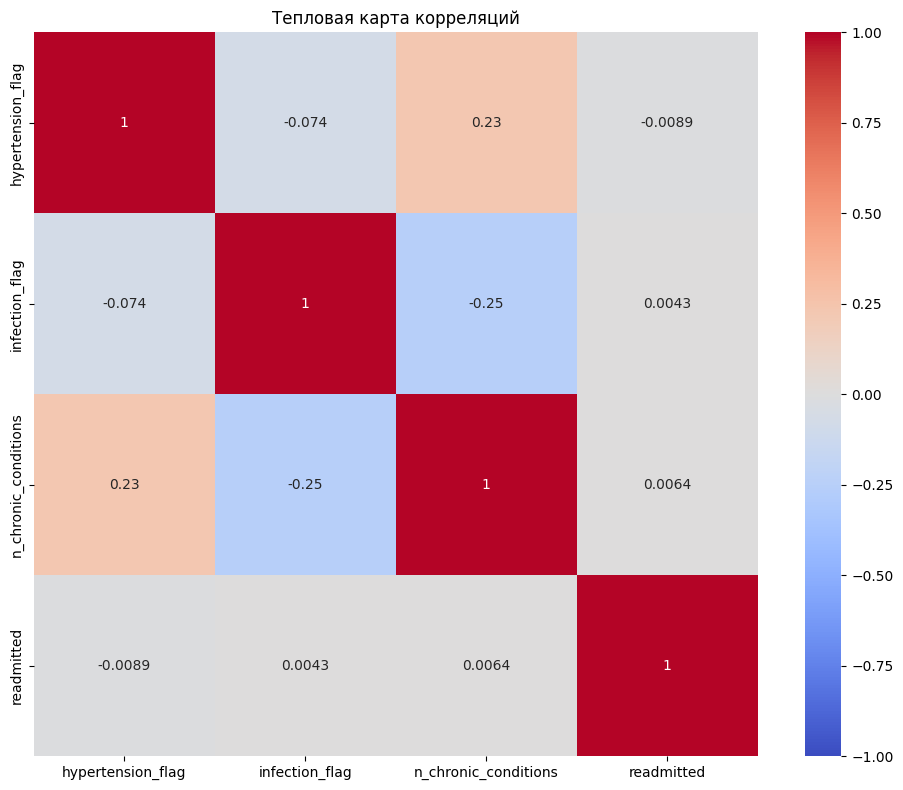

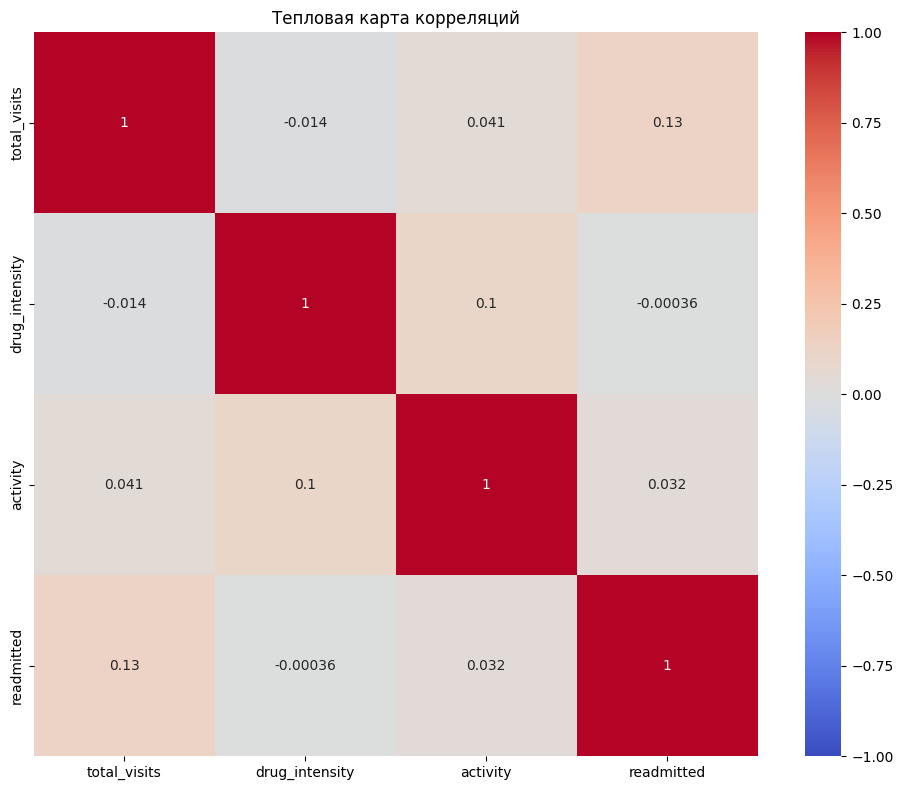

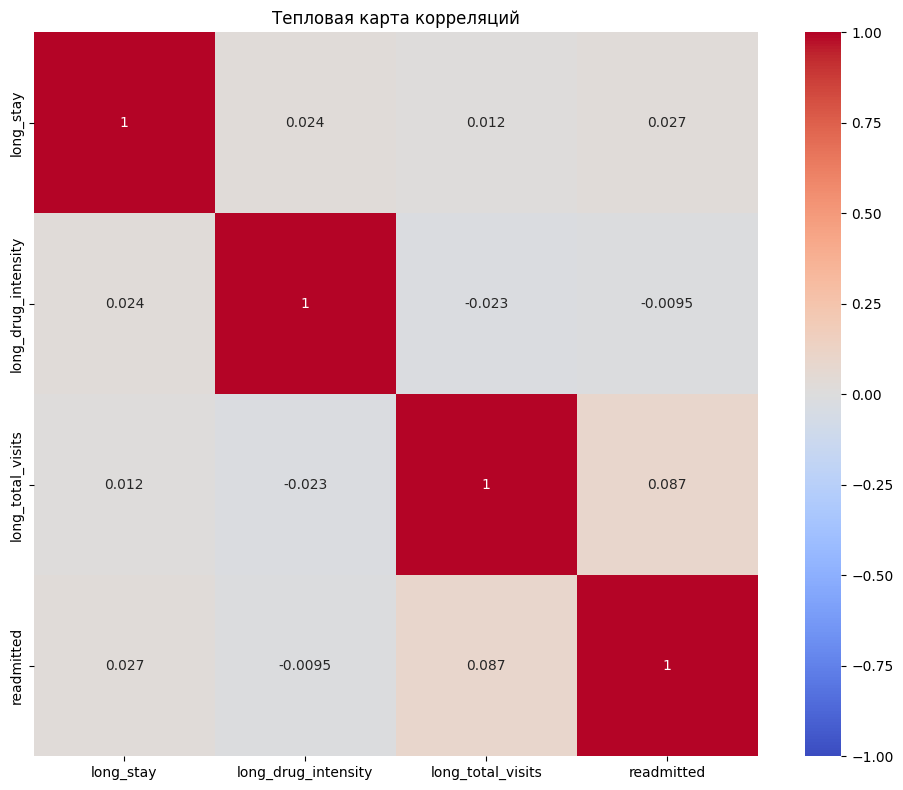

In [83]:
diag_1_cols = [c for c in df_diag.columns if c.startswith('diag_1_')]
df_all = [
    df_demograp,
    df[diag_1_cols],
    df_med,
    df_other,
    df_adm,
    df_an,
    df_drug,
    df_activ,
    df_visits,
    df_flag,
    df_agreg,
    df_binar
]

for dfi in df_all:
    dfi = pd.concat([dfi, df['readmitted']], axis=1).iloc[train_idx]
    corr_matrix = dfi.corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap='coolwarm',
        vmin=-1,
        vmax=1,
        square=True
    )
    plt.title('Тепловая карта корреляций')
    plt.tight_layout()
    plt.show()


### Посмотрев тепловые карты для всех подгрупп можно сделать вывод, что линейной зависимости с целевой переменной нет, логистическая регрессия вероятнее всего будет давать плохой результат. Деревья могут выявить нелинейные зависимости.

#### 1: обработка пропусков
1. Были удалены столбцы с очень большим количеством пропусков, более 90-95%, никакой информации модели они не дадут.
2. Заменены пропуски на 'неизвестно' в двух ключевых лабораторных признаков для диабета, это важная информация для модели, но много пропусков поскольку в датасете присутствуют заболевания разных областей, а не только болезни крови. Такая же логика была применена к столбцам медицинская специальность и код плательщика.
3. Для столбца `race` пропуски сохранены как отдельная категория `Missing`, без объединения категорий по target.
4. Для столбца `gender` удалены 3 строки с пропусками; target при принятии решения не использовался.
5. Для диагнозов было принято решение заменить пропуски на неизвестно, поскольку есть вероятность, что диагноз не удалось поставить.  
#### 2: стратегии инженерии признаков
1. Для начала просмотрев столбцы можно выяснить какую именно информацию мы можем достать из датасета. Например если бы у нас был только столбец с мед. специальностью, то мы бы доставали оттуда область болезни, но поскольку у нас есть столбец диагноз и вопрос с областью закрыт, из мед. специальности мы можем достать тип лечения, так как терапевтическая кардиология и хирургическая дают представление о степени тяжести состояния пациента. `payer_code` рассматривается как номинальный категориальный признак без предположения о финансовом состоянии пациента.
2. Объединение в смысловые группы и последующий просмотр корреляции, если бы признаки коррелировали между друг другом, что может вызывать проблемы для моделей, особенно для регрессии.
3. Для групп были созданы агрегирующие признаки. Можно протестировать модель без них с основными столбцами, с основными столбцами и с агрегирующими, и только с агрегирующими. Разница может быть существенной между этими моделями.
4. Было выдвинуто 4 гипотезы о взаимодействии между признаками. Это добавляет модели нелинейность. Важно для линейной регрессии, где не учитывается нелинейность.


## 3. Построение и сравнение моделей

### 3.1. Разделение данных на обучающую, тестовую и валидационную выборки

In [84]:
X1 = df1
X2 = df2
X3 = df3
X4 = df4
X5 = df5

y = df['readmitted']
groups = df['patient_nbr']


In [85]:
def split_by_index(X):
    return X.iloc[train_idx].copy(), X.iloc[val_idx].copy(), X.iloc[test_idx].copy()

X1_train, X1_val, X1_test = split_by_index(X1)
X2_train, X2_val, X2_test = split_by_index(X2)
X3_train, X3_val, X3_test = split_by_index(X3)
X4_train, X4_val, X4_test = split_by_index(X4)
X5_train, X5_val, X5_test = split_by_index(X5)

y1_train, y1_val, y1_test = y.iloc[train_idx].copy(), y.iloc[val_idx].copy(), y.iloc[test_idx].copy()
y2_train, y2_val, y2_test = y1_train.copy(), y1_val.copy(), y1_test.copy()
y3_train, y3_val, y3_test = y1_train.copy(), y1_val.copy(), y1_test.copy()
y4_train, y4_val, y4_test = y1_train.copy(), y1_val.copy(), y1_test.copy()
y5_train, y5_val, y5_test = y1_train.copy(), y1_val.copy(), y1_test.copy()

groups_train = groups.iloc[train_idx].copy()
groups_val = groups.iloc[val_idx].copy()
groups_test = groups.iloc[test_idx].copy()


Проверка распределения целевой переменной

In [86]:
y1_total = [y1_train, y1_val, y1_test]
for i in y1_total:
    print(i.value_counts(normalize=True))

print('train ∩ validation:', len(set(groups_train) & set(groups_val)))
print('train ∩ test:', len(set(groups_train) & set(groups_test)))
print('validation ∩ test:', len(set(groups_val) & set(groups_test)))

readmitted
0    0.887369
1    0.112631
Name: proportion, dtype: float64
readmitted
0    0.889161
1    0.110839
Name: proportion, dtype: float64
readmitted
0    0.890758
1    0.109242
Name: proportion, dtype: float64
train ∩ validation: 0
train ∩ test: 0
validation ∩ test: 0


Масштабируем числовые признаки (только на трейне)

In [87]:
X_train_total = [X1_train, X2_train, X3_train, X4_train, X5_train]
X_val_total = [X1_val, X2_val, X3_val, X4_val, X5_val]
X_test_total = [X1_test, X2_test, X3_test, X4_test, X5_test]
y_train_total = [y1_train, y2_train, y3_train, y4_train, y5_train]
y_val_total = [y1_val, y2_val, y3_val, y4_val, y5_val]
y_test_total = [y1_test, y2_test, y3_test, y4_test, y5_test]

In [ ]:
robust_cols = {
    1: ['num_lab_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient'],
    2: ['num_lab_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'activity', 'total_visits'],
    3: ['activity', 'total_visits'],
    4: [],
    5: [],
}

minmax_cols = {
    1: ['num_procedures', 'number_diagnoses', 'age'],
    2: ['num_procedures', 'number_diagnoses', 'drug_intensity', 'age'],
    3: ['drug_intensity', 'age'],
    4: ['age'],
    5: ['age_num_inpatient', 'gender_diabetes', 'longstay_procedures', 'infection_time'],
}

X_train_total_scaled = [x.copy() for x in X_train_total]
X_val_total_scaled = [x.copy() for x in X_val_total]
X_test_total_scaled = [x.copy() for x in X_test_total]

scalers_robust = {}
scalers_minmax = {}

for idx, dfi in enumerate(X_train_total_scaled, start=1):
    rcols = [c for c in robust_cols[idx] if c in dfi.columns]
    mcols = [c for c in minmax_cols[idx] if c in dfi.columns]

    if rcols:
        scaler_r = RobustScaler()
        dfi.loc[:, rcols] = scaler_r.fit_transform(dfi[rcols])
        scalers_robust[idx] = scaler_r
    if mcols:
        scaler_m = MinMaxScaler()
        dfi.loc[:, mcols] = scaler_m.fit_transform(dfi[mcols])
        scalers_minmax[idx] = scaler_m

for data_list in [X_val_total_scaled, X_test_total_scaled]:
    for idx, dfi in enumerate(data_list, start=1):
        rcols = [c for c in robust_cols[idx] if c in dfi.columns]
        mcols = [c for c in minmax_cols[idx] if c in dfi.columns]
        if rcols:
            dfi.loc[:, rcols] = scalers_robust[idx].transform(dfi[rcols])
        if mcols:
            dfi.loc[:, mcols] = scalers_minmax[idx].transform(dfi[mcols])


Семплинг

In [89]:
smote_tomek = SMOTETomek(random_state=42)

X_train_total_res, y_train_total_res = [], []

for idx, (Xtr, ytr) in enumerate(zip(X_train_total_scaled, y_train_total), start=1):
    X_res, y_res = smote_tomek.fit_resample(Xtr, ytr)
    X_train_total_res.append(X_res)
    y_train_total_res.append(y_res)

    print(f"\nX{idx}_train:")
    print("До SMOTE + Tomek:", ytr.value_counts(normalize=True))
    print("После SMOTE + Tomek:", y_res.value_counts(normalize=True))



X1_train:
До SMOTE + Tomek: readmitted
0    0.887369
1    0.112631
Name: proportion, dtype: float64
После SMOTE + Tomek: readmitted
0    0.5
1    0.5
Name: proportion, dtype: float64

X2_train:
До SMOTE + Tomek: readmitted
0    0.887369
1    0.112631
Name: proportion, dtype: float64
После SMOTE + Tomek: readmitted
0    0.5
1    0.5
Name: proportion, dtype: float64

X3_train:
До SMOTE + Tomek: readmitted
0    0.887369
1    0.112631
Name: proportion, dtype: float64
После SMOTE + Tomek: readmitted
0    0.5
1    0.5
Name: proportion, dtype: float64

X4_train:
До SMOTE + Tomek: readmitted
0    0.887369
1    0.112631
Name: proportion, dtype: float64
После SMOTE + Tomek: readmitted
0    0.5
1    0.5
Name: proportion, dtype: float64

X5_train:
До SMOTE + Tomek: readmitted
0    0.887369
1    0.112631
Name: proportion, dtype: float64
После SMOTE + Tomek: readmitted
0    0.5
1    0.5
Name: proportion, dtype: float64


In [90]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=42, class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
}

baseline_results = {}

for idx, (Xtr, ytr, Xte, yte) in enumerate(
    zip(X_train_total_res, y_train_total_res, X_val_total_scaled, y_val_total),
    start=1
):
    print('-'*70)
    print(f"\nДатасет X{idx}")
    baseline_results[f'X{idx}'] = {}

    for name, model in models.items():
        model.fit(Xtr, ytr)
        y_pred = model.predict(Xte)
        report = classification_report(yte, y_pred, output_dict=True, zero_division=0)

        baseline_results[f'X{idx}'][name] = report['1']['f1-score']

        print(f"\n{name}")
        print(classification_report(yte, y_pred, digits=3, zero_division=0))


----------------------------------------------------------------------

Датасет X1

Logistic Regression
              precision    recall  f1-score   support

           0      0.900     0.704     0.790     18162
           1      0.136     0.373     0.199      2264

    accuracy                          0.667     20426
   macro avg      0.518     0.538     0.494     20426
weighted avg      0.815     0.667     0.724     20426


Decision Tree
              precision    recall  f1-score   support

           0      0.893     0.876     0.884     18162
           1      0.138     0.160     0.148      2264

    accuracy                          0.796     20426
   macro avg      0.516     0.518     0.516     20426
weighted avg      0.810     0.796     0.803     20426


Random Forest
              precision    recall  f1-score   support

           0      0.890     0.999     0.941     18162
           1      0.458     0.005     0.010      2264

    accuracy                          0.889     

#### Сравнение моделей по F1-score для класса 1 для изначально созданных моделей с семплингом

In [91]:
pd.DataFrame(baseline_results).T.rename(columns={
    'Logistic Regression': 'Logistic Regression',
    'Decision Tree': 'Decision Tree',
    'Random Forest': 'Random Forest'
}).round(3)


,Logistic Regression,Decision Tree,Random Forest
X1,0.199,0.148,0.010
X2,0.144,0.146,0.010
X3,0.200,0.156,0.014
X4,0.180,0.146,0.040
X5,0.199,0.160,0.041


In [92]:
diag_2_3 = [c for c in df_diag.columns if c.startswith('diag_2_') or c.startswith('diag_3_')]
df_race = df_demograp[race_cols]


In [93]:
cols_to_drop = (
    list(df_diag.columns)
    + list(df_med.columns)
    + list(df_an.columns)
    + list(df_adm.columns)
    + list(df_race.columns)
    + list(payer_cols)
)

def drop_cols(X_train, X_val, X_test, cols):
    cols_existing = [c for c in cols if c in X_train.columns]
    return (
        X_train.drop(cols_existing, axis=1),
        X_val.drop(cols_existing, axis=1),
        X_test.drop(cols_existing, axis=1)
    )

X1new_train, X1new_val, X1new_test = drop_cols(X1_train, X1_val, X1_test, cols_to_drop)
X2new_train, X2new_val, X2new_test = drop_cols(X2_train, X2_val, X2_test, cols_to_drop)
X3new_train, X3new_val, X3new_test = drop_cols(X3_train, X3_val, X3_test, cols_to_drop)
X4new_train, X4new_val, X4new_test = drop_cols(X4_train, X4_val, X4_test, cols_to_drop)
X5new_train, X5new_val, X5new_test = drop_cols(X5_train, X5_val, X5_test, cols_to_drop)


In [94]:
X_train_total_new = [X1new_train, X2new_train, X3new_train, X4new_train, X5new_train]
X_val_total_new = [X1new_val, X2new_val, X3new_val, X4new_val, X5new_val]
X_test_total_new = [X1new_test, X2new_test, X3new_test, X4new_test, X5new_test]
y_train_total_new = [y1_train, y2_train, y3_train, y4_train, y5_train]
y_val_total_new = [y1_val, y2_val, y3_val, y4_val, y5_val]
y_test_total_new = [y1_test, y2_test, y3_test, y4_test, y5_test]
def get_dataset_split(name):
    mapping = {
        'X1': (X1_train, X1_val, X1_test, y1_train, y1_val, y1_test),
        'X2': (X2_train, X2_val, X2_test, y2_train, y2_val, y2_test),
        'X3': (X3_train, X3_val, X3_test, y3_train, y3_val, y3_test),
        'X4': (X4_train, X4_val, X4_test, y4_train, y4_val, y4_test),
        'X5': (X5_train, X5_val, X5_test, y5_train, y5_val, y5_test),
        'X12': (X1new_train, X1new_val, X1new_test, y1_train, y1_val, y1_test),
        'X22_res': (X2new_train, X2new_val, X2new_test, y2_train, y2_val, y2_test),
        'X32': (X3new_train, X3new_val, X3new_test, y3_train, y3_val, y3_test),
        'X42': (X4new_train, X4new_val, X4new_test, y4_train, y4_val, y4_test),
        'X52': (X5new_train, X5new_val, X5new_test, y5_train, y5_val, y5_test),
        'X21': (X1_train, X1_val, X1_test, y1_train, y1_val, y1_test),
        'X22': (X2_train, X2_val, X2_test, y2_train, y2_val, y2_test),
        'X23': (X3_train, X3_val, X3_test, y3_train, y3_val, y3_test),
        'X24': (X4_train, X4_val, X4_test, y4_train, y4_val, y4_test),
        'X25': (X5_train, X5_val, X5_test, y5_train, y5_val, y5_test),
        'X212': (X1new_train, X1new_val, X1new_test, y1_train, y1_val, y1_test),
        'X222': (X2new_train, X2new_val, X2new_test, y2_train, y2_val, y2_test),
        'X232': (X3new_train, X3new_val, X3new_test, y3_train, y3_val, y3_test),
        'X242': (X4new_train, X4new_val, X4new_test, y4_train, y4_val, y4_test),
        'X252': (X5new_train, X5new_val, X5new_test, y5_train, y5_val, y5_test),
    }
    return mapping[name]


In [95]:
for idx, (Xtr, Xva, Xte) in enumerate(zip(X_train_total_new, X_val_total_new, X_test_total_new), start=1):
    print(f"X{idx}new: train={Xtr.shape}, val={Xva.shape}, test={Xte.shape}")

X1new: train=(61244, 23), val=(20426, 23), test=(20093, 23)
X2new: train=(61244, 26), val=(20426, 26), test=(20093, 26)
X3new: train=(61244, 11), val=(20426, 11), test=(20093, 11)
X4new: train=(61244, 10), val=(20426, 10), test=(20093, 10)
X5new: train=(61244, 14), val=(20426, 14), test=(20093, 14)


In [96]:
smote_tomek_new = SMOTETomek(random_state=42)

X_train_total_res_new, y_train_total_res_new = [], []
X_val_total_new_scaled = []

for idx, (Xtr, Xva, ytr) in enumerate(zip(X_train_total_new, X_val_total_new, y_train_total_new), start=1):
    scaler = StandardScaler()
    Xtr_scaled = pd.DataFrame(
        scaler.fit_transform(Xtr),
        columns=Xtr.columns,
        index=Xtr.index
    )
    Xva_scaled = pd.DataFrame(
        scaler.transform(Xva),
        columns=Xva.columns,
        index=Xva.index
    )
    X_res, y_res = smote_tomek_new.fit_resample(Xtr_scaled, ytr)
    X_train_total_res_new.append(X_res)
    y_train_total_res_new.append(y_res)
    X_val_total_new_scaled.append(Xva_scaled)

    print(f"\nX{idx}_train:")
    print("До SMOTE + Tomek:", ytr.value_counts(normalize=True))
    print("После SMOTE + Tomek:", y_res.value_counts(normalize=True))



X1_train:
До SMOTE + Tomek: readmitted
0    0.887369
1    0.112631
Name: proportion, dtype: float64
После SMOTE + Tomek: readmitted
0    0.5
1    0.5
Name: proportion, dtype: float64

X2_train:
До SMOTE + Tomek: readmitted
0    0.887369
1    0.112631
Name: proportion, dtype: float64
После SMOTE + Tomek: readmitted
0    0.5
1    0.5
Name: proportion, dtype: float64

X3_train:
До SMOTE + Tomek: readmitted
0    0.887369
1    0.112631
Name: proportion, dtype: float64
После SMOTE + Tomek: readmitted
0    0.5
1    0.5
Name: proportion, dtype: float64

X4_train:
До SMOTE + Tomek: readmitted
0    0.887369
1    0.112631
Name: proportion, dtype: float64
После SMOTE + Tomek: readmitted
0    0.5
1    0.5
Name: proportion, dtype: float64

X5_train:
До SMOTE + Tomek: readmitted
0    0.887369
1    0.112631
Name: proportion, dtype: float64
После SMOTE + Tomek: readmitted
0    0.5
1    0.5
Name: proportion, dtype: float64


In [97]:
models_new = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
}

baseline_results_new = {}

for idx, (Xtr, ytr, Xte, yte) in enumerate(
    zip(X_train_total_res_new, y_train_total_res_new, X_val_total_new_scaled, y_val_total_new),
    start=1
):
    print('-'*70)
    print(f"\nДатасет X{idx}")
    baseline_results_new[f'X{idx}'] = {}

    for name, model in models_new.items():
        model.fit(Xtr, ytr)
        y_pred = model.predict(Xte)
        report = classification_report(yte, y_pred, output_dict=True, zero_division=0)

        baseline_results_new[f'X{idx}'][name] = report['1']['f1-score']

        print(f"\n{name}")
        print(classification_report(yte, y_pred, digits=3, zero_division=0))


----------------------------------------------------------------------

Датасет X1

Logistic Regression
              precision    recall  f1-score   support

           0      0.914     0.669     0.772     18162
           1      0.157     0.494     0.238      2264

    accuracy                          0.649     20426
   macro avg      0.535     0.581     0.505     20426
weighted avg      0.830     0.649     0.713     20426


Decision Tree
              precision    recall  f1-score   support

           0      0.893     0.859     0.876     18162
           1      0.136     0.178     0.155      2264

    accuracy                          0.784     20426
   macro avg      0.515     0.519     0.515     20426
weighted avg      0.810     0.784     0.796     20426


Random Forest
              precision    recall  f1-score   support

           0      0.890     0.992     0.938     18162
           1      0.226     0.019     0.036      2264

    accuracy                          0.884     

In [98]:
pd.DataFrame(baseline_results_new).T.round(3)


,Logistic Regression,Decision Tree,Random Forest
X1,0.238,0.155,0.036
X2,0.237,0.153,0.035
X3,0.231,0.139,0.131
X4,0.214,0.192,0.194
X5,0.236,0.182,0.181


### 3.3. Кросс-валидация и поиск гиперпараметров (GridSearchCV).

#### Логистическая регрессия

Обучение с F1

In [99]:
param_grid_logreg = [
    # для L1
    {
        'penalty': ['l1'],
        'solver': ['liblinear', 'saga'],
        'C': [0.00001, 0.0001, 0.001],
        'max_iter': [500]
    },
    # для L2
    {
        'penalty': ['l2'],
        'solver': ['lbfgs', 'liblinear', 'sag', 'saga'],
        'C': [ 0.00001, 0.0001, 0.001],
        'max_iter': [500]
    }
]


In [ ]:
datasets_all = {
    "X1": (X1_train, X1_val, y1_train, y1_val, groups_train, True),
    "X2": (X2_train, X2_val, y2_train, y2_val, groups_train, True),
    "X3": (X3_train, X3_val, y3_train, y3_val, groups_train, True),
    "X4": (X4_train, X4_val, y4_train, y4_val, groups_train, True),
    "X5": (X5_train, X5_val, y5_train, y5_val, groups_train, True),
    "X12": (X1new_train, X1new_val, y1_train, y1_val, groups_train, True),
    "X22_res": (X2new_train, X2new_val, y2_train, y2_val, groups_train, True),
    "X32": (X3new_train, X3new_val, y3_train, y3_val, groups_train, True),
    "X42": (X4new_train, X4new_val, y4_train, y4_val, groups_train, True),
    "X52": (X5new_train, X5new_val, y5_train, y5_val, groups_train, True),
    "X21": (X1_train, X1_val, y1_train, y1_val, groups_train, False),
    "X22": (X2_train, X2_val, y2_train, y2_val, groups_train, False),
    "X23": (X3_train, X3_val, y3_train, y3_val, groups_train, False),
    "X24": (X4_train, X4_val, y4_train, y4_val, groups_train, False),
    "X25": (X5_train, X5_val, y5_train, y5_val, groups_train, False),
    "X212": (X1new_train, X1new_val, y1_train, y1_val, groups_train, False),
    "X222": (X2new_train, X2new_val, y2_train, y2_val, groups_train, False),
    "X232": (X3new_train, X3new_val, y3_train, y3_val, groups_train, False),
    "X242": (X4new_train, X4new_val, y4_train, y4_val, groups_train, False),
    "X252": (X5new_train, X5new_val, y5_train, y5_val, groups_train, False),
}

datasets_tree = {
    name: datasets_all[name]
    for name in ["X22", "X23", "X232"]
}

datasets_rf = {
    name: datasets_all[name]
    for name in ["X22", "X23", "X24", "X25", "X212", "X222", "X232", "X242", "X252"]
}

scorer_f1 = make_scorer(f1_score, pos_label=1)
scorer_recall = make_scorer(recall_score, pos_label=1)


def run_grid_search(
    datasets,
    base_model,
    param_grid,
    scorer,
    model_name,
    score_key,
    use_scaler=False
):
    results = {}
    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

    if isinstance(param_grid, list):
        grid_params = [
            {f"model__{key}": value for key, value in params.items()}
            for params in param_grid
        ]
    else:
        grid_params = {
            f"model__{key}": value
            for key, value in param_grid.items()
        }

    for name, (X_train, X_val, y_train, y_val, groups_cv, use_sampling) in datasets.items():
        print(f"\n{model_name} для {name}")

        steps = []
        if use_scaler:
            steps.append(("scaler", StandardScaler()))
        if use_sampling:
            steps.append(("sampler", SMOTETomek(random_state=42)))
        steps.append(("model", base_model))

        model = ImbPipeline(steps)

        grid = GridSearchCV(
            model,
            grid_params,
            cv=cv,
            scoring=scorer,
            n_jobs=-1,
            verbose=2
        )
        grid.fit(X_train, y_train, groups=groups_cv)

        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_val)

        report = classification_report(
            y_val,
            y_pred,
            digits=3,
            output_dict=True,
            zero_division=0
        )

        best_params = {
            key.replace("model__", ""): value
            for key, value in grid.best_params_.items()
        }

        print("Лучшие параметры:", best_params)
        print("Лучший CV score:", grid.best_score_)
        print(f"Validation Report ({name})")
        print(classification_report(y_val, y_pred, digits=3, zero_division=0))

        results[name] = {
            "best_params": best_params,
            score_key: grid.best_score_,
            "val_f1": report["1"]["f1-score"],
            "val_recall": report["1"]["recall"],
            "val_precision": report["1"]["precision"],
            "best_estimator": best_model
        }
        print("-" * 70)

    return results

In [ ]:

def results_table(results, score_key, score_label):
    return pd.DataFrame([
        {
            "Модель": name,
            score_label: values[score_key],
            "F1 (класс 1)": values["val_f1"],
            "Recall (класс 1)": values["val_recall"]
        }
        for name, values in results.items()
    ]).set_index("Модель").round(4)


results_logreg_f1 = run_grid_search(
    datasets=datasets_all,
    base_model=LogisticRegression(random_state=42, class_weight="balanced"),
    param_grid=param_grid_logreg,
    scorer=scorer_f1,
    model_name="LogisticRegression",
    score_key="best_f1",
    use_scaler=True
)



LogisticRegression для X1
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Лучшие параметры: {'C': 0.0001, 'max_iter': 500, 'penalty': 'l1', 'solver': 'liblinear'}
Лучший CV score: 0.2528153210017291
Validation Report (X1)
              precision    recall  f1-score   support

           0      0.913     0.683     0.781     18162
           1      0.158     0.477     0.237      2264

    accuracy                          0.660     20426
   macro avg      0.535     0.580     0.509     20426
weighted avg      0.829     0.660     0.721     20426

----------------------------------------------------------------------

LogisticRegression для X2
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Лучшие параметры: {'C': 0.0001, 'max_iter': 500, 'penalty': 'l1', 'solver': 'liblinear'}
Лучший CV score: 0.2528153210017291
Validation Report (X2)
              precision    recall  f1-score   support

           0      0.913     0.683     0.781     18162
           1      0.1

In [101]:
results_table(results_logreg_f1, "best_f1", "Лучший F1 на CV")


,Лучший F1 на CV,F1 (класс 1),Recall (класс 1)
Модель,,,
X1,0.2528,0.2372,0.4766
X2,0.2528,0.2372,0.4766
X3,0.2421,0.2309,0.4898
X4,0.2197,0.2156,0.5278
X5,0.2451,0.2351,0.4541
X12,0.2528,0.2372,0.4766
X22_res,0.2528,0.2372,0.4766
X32,0.2438,0.2315,0.4828
X42,0.2143,0.2137,0.4841


Обучение с recall

In [102]:
results_logreg_recall = run_grid_search(
    datasets=datasets_all,
    base_model=LogisticRegression(random_state=42, class_weight="balanced"),
    param_grid=param_grid_logreg,
    scorer=scorer_recall,
    model_name="LogisticRegression",
    score_key="best_recall",
    use_scaler=True
)



LogisticRegression для X1
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Лучшие параметры: {'C': 1e-05, 'max_iter': 500, 'penalty': 'l2', 'solver': 'liblinear'}
Лучший CV score: 0.6278710898337286
Validation Report (X1)
              precision    recall  f1-score   support

           0      0.917     0.559     0.695     18162
           1      0.144     0.595     0.232      2264

    accuracy                          0.563     20426
   macro avg      0.530     0.577     0.463     20426
weighted avg      0.831     0.563     0.643     20426

----------------------------------------------------------------------

LogisticRegression для X2
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Лучшие параметры: {'C': 1e-05, 'max_iter': 500, 'penalty': 'l2', 'solver': 'liblinear'}
Лучший CV score: 0.6168646925229836
Validation Report (X2)
              precision    recall  f1-score   support

           0      0.917     0.573     0.705     18162
           1      0.146

In [103]:
results_table(results_logreg_recall, "best_recall", "Лучший recall на CV")


,Лучший recall на CV,F1 (класс 1),Recall (класс 1)
Модель,,,
X1,0.6279,0.2317,0.5945
X2,0.6169,0.2338,0.5857
X3,0.6211,0.2243,0.5954
X4,0.5964,0.2121,0.5764
X5,0.5963,0.2281,0.5755
X12,0.5773,0.2400,0.5592
X22_res,0.8000,0.1996,1.0000
X32,0.8000,0.2274,0.3741
X42,1.0000,0.0000,0.0000


### Дерево решений

In [104]:
param_grid_extended = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2],
    'min_samples_leaf': [2, 4, 8],
    'max_leaf_nodes': [100, 300, 600],
    'max_features': ['log2']
}


In [105]:
results_tree_f1 = run_grid_search(
    datasets=datasets_tree,
    base_model=DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    param_grid=param_grid_extended,
    scorer=scorer_f1,
    model_name="DecisionTreeClassifier",
    score_key="best_f1",
    use_scaler=False
)



DecisionTreeClassifier для X22
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Лучшие параметры: {'criterion': 'entropy', 'max_depth': 10, 'max_features': 'log2', 'max_leaf_nodes': 300, 'min_samples_leaf': 4, 'min_samples_split': 2}
Лучший CV score: 0.22665611155058377
Validation Report (X22)
              precision    recall  f1-score   support

           0      0.911     0.571     0.702     18162
           1      0.139     0.555     0.222      2264

    accuracy                          0.569     20426
   macro avg      0.525     0.563     0.462     20426
weighted avg      0.826     0.569     0.649     20426

----------------------------------------------------------------------

DecisionTreeClassifier для X23
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Лучшие параметры: {'criterion': 'entropy', 'max_depth': 15, 'max_features': 'log2', 'max_leaf_nodes': 300, 'min_samples_leaf': 2, 'min_samples_split': 2}
Лучший CV score: 0.21791292155874564
Validati

In [106]:
results_table(results_tree_f1, "best_f1", "Лучший F1 на CV")


,Лучший F1 на CV,F1 (класс 1),Recall (класс 1)
Модель,,,
X22,0.2267,0.2221,0.5552
X23,0.2179,0.2155,0.6215
X232,0.2331,0.2214,0.5508


In [107]:
results_tree_recall = run_grid_search(
    datasets=datasets_tree,
    base_model=DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    param_grid=param_grid_extended,
    scorer=scorer_recall,
    model_name="DecisionTreeClassifier",
    score_key="best_recall",
    use_scaler=False
)

results_table(results_tree_recall, "best_recall", "Лучший recall на CV")



DecisionTreeClassifier для X22
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Лучшие параметры: {'criterion': 'gini', 'max_depth': 15, 'max_features': 'log2', 'max_leaf_nodes': 600, 'min_samples_leaf': 4, 'min_samples_split': 2}
Лучший CV score: 0.5693584592131902
Validation Report (X22)
              precision    recall  f1-score   support

           0      0.907     0.614     0.732     18162
           1      0.138     0.498     0.217      2264

    accuracy                          0.601     20426
   macro avg      0.523     0.556     0.474     20426
weighted avg      0.822     0.601     0.675     20426

----------------------------------------------------------------------

DecisionTreeClassifier для X23
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Лучшие параметры: {'criterion': 'gini', 'max_depth': 5, 'max_features': 'log2', 'max_leaf_nodes': 100, 'min_samples_leaf': 8, 'min_samples_split': 2}
Лучший CV score: 0.6465936184839183
Validation Report

,Лучший recall на CV,F1 (класс 1),Recall (класс 1)
Модель,,,
X22,0.5694,0.2166,0.4978
X23,0.6466,0.1991,0.6007
X232,0.6608,0.2088,0.4483


Случайный лес

In [108]:
param_grid_rf = {
    'n_estimators': [25],             # количество деревьев
    'max_depth': [10, 30, 50],         # максимальная глубина
    'min_samples_split': [2, 5, 10],             # минимальное кол-во образцов для разбиения узла
    'min_samples_leaf': [1, 2, 4],               # минимальное кол-во образцов в листе
    'max_features': ['sqrt', 'log2'],      # стратегия выбора признаков
    'class_weight': ['balanced', 'balanced_subsample']
}

In [109]:
results_rf_f1 = run_grid_search(
    datasets=datasets_rf,
    base_model=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    scorer=scorer_f1,
    model_name="Random Forest",
    score_key="best_f1",
    use_scaler=False
)



Random Forest для X22
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Лучшие параметры: {'class_weight': 'balanced_subsample', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 25}
Лучший CV score: 0.26262984964479974
Validation Report (X22)
              precision    recall  f1-score   support

           0      0.915     0.700     0.793     18162
           1      0.165     0.476     0.245      2264

    accuracy                          0.675     20426
   macro avg      0.540     0.588     0.519     20426
weighted avg      0.832     0.675     0.732     20426

----------------------------------------------------------------------

Random Forest для X23
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Лучшие параметры: {'class_weight': 'balanced_subsample', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 25}
Лучший CV score: 0.25763789285005306
V

In [110]:
results_table(results_rf_f1, "best_f1", "Лучший F1 на CV")


,Лучший F1 на CV,F1 (класс 1),Recall (класс 1)
Модель,,,
X22,0.2626,0.2452,0.4761
X23,0.2576,0.2421,0.4867
X24,0.2380,0.2305,0.4262
X25,0.2587,0.2454,0.4978
X212,0.2512,0.2449,0.4311
X222,0.2539,0.2448,0.4249
X232,0.2374,0.2258,0.4315
X242,0.2044,0.2056,0.4545
X252,0.2450,0.2372,0.4722


In [111]:
results_rf_recall = run_grid_search(
    datasets=datasets_rf,
    base_model=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    scorer=scorer_recall,
    model_name="Random Forest",
    score_key="best_recall",
    use_scaler=False
)



Random Forest для X22
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Лучшие параметры: {'class_weight': 'balanced_subsample', 'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 25}
Лучший CV score: 0.4993341088521735
Validation Report (X22)
              precision    recall  f1-score   support

           0      0.914     0.691     0.787     18162
           1      0.162     0.479     0.242      2264

    accuracy                          0.667     20426
   macro avg      0.538     0.585     0.514     20426
weighted avg      0.831     0.667     0.726     20426

----------------------------------------------------------------------

Random Forest для X23
Fitting 5 folds for each of 108 candidates, totalling 540 fits
Лучшие параметры: {'class_weight': 'balanced', 'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 25}
Лучший CV score: 0.5292686096859069
Validation Re

In [112]:
results_table(results_rf_recall, "best_recall", "Лучший recall на CV")


,Лучший recall на CV,F1 (класс 1),Recall (класс 1)
Модель,,,
X22,0.4993,0.2420,0.4792
X23,0.5293,0.2359,0.4770
X24,0.4800,0.2293,0.4801
X25,0.5143,0.2454,0.4978
X212,0.4446,0.2389,0.4421
X222,0.4361,0.2432,0.4161
X232,0.4493,0.2258,0.4315
X242,0.4703,0.2056,0.4545
X252,0.4840,0.2372,0.4722


### 3.4. Выбор финальной модели по validation


In [113]:
def best_by_metric(results_dict, metric, allowed_names=None):
    items = results_dict.items()
    if allowed_names is not None:
        items = [(name, values) for name, values in items if name in allowed_names]
    name, values = max(items, key=lambda item: item[1][metric])
    return name, values

no_sampling_names = {'X21', 'X22', 'X23', 'X24', 'X25', 'X212', 'X222', 'X232', 'X242', 'X252'}

lr_f1_name, lr_f1_info = best_by_metric(results_logreg_f1, 'val_f1', no_sampling_names)
lr_recall_name, lr_recall_info = best_by_metric(results_logreg_recall, 'val_recall', no_sampling_names)

tree_f1_name, tree_f1_info = best_by_metric(results_tree_f1, 'val_f1')
tree_recall_name, tree_recall_info = best_by_metric(results_tree_recall, 'val_recall')

rf_f1_name, rf_f1_info = best_by_metric(results_rf_f1, 'val_f1')
rf_recall_name, rf_recall_info = best_by_metric(results_rf_recall, 'val_recall')

f1_candidates = {
    'Logistic Regression': (lr_f1_name, lr_f1_info),
    'Decision Tree': (tree_f1_name, tree_f1_info),
    'Random Forest': (rf_f1_name, rf_f1_info),
}

final_family, (final_name, final_info) = max(
    f1_candidates.items(),
    key=lambda item: item[1][1]['val_f1']
)

final_model = final_info['best_estimator']
X_train_final, X_val_final, X_test_final, y_train_final, y_val_final, y_test_final = get_dataset_split(final_name)

print('Финальная модель:', final_family, final_name)
print('Validation F1:', final_info['val_f1'])
print('Validation recall:', final_info['val_recall'])
print('Validation precision:', final_info['val_precision'])
print('Параметры:', final_info['best_params'])


Финальная модель: Random Forest X25
Validation F1: 0.24537339429566732
Validation recall: 0.49779151943462896
Validation precision: 0.1628142155446403
Параметры: {'class_weight': 'balanced_subsample', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 25}


Лучшая логистическая регрессия по recall


In [114]:
print(lr_recall_name)
print(lr_recall_info['best_params'])
print('F1:', lr_recall_info['val_f1'])
print('Recall:', lr_recall_info['val_recall'])


X22
{'C': 1e-05, 'max_iter': 500, 'penalty': 'l1', 'solver': 'saga'}
F1: 0.19955927721463199
Recall: 1.0


Тут конечно неадекватно, тк предсказывает практически всё классом 1, это вырожденная модель. Поэтому на самом деле тут лучшая модель LR X21, где recall = 0.571, F1 = 0.236

Лучшая логистическая регрессия по F1


In [115]:
print(lr_f1_name)
print(lr_f1_info['best_params'])
print('F1:', lr_f1_info['val_f1'])
print('Recall:', lr_f1_info['val_recall'])


X21
{'C': 0.001, 'max_iter': 500, 'penalty': 'l1', 'solver': 'saga'}
F1: 0.24257304198379573
Recall: 0.4363957597173145


Лучшее дерево решений по recall


In [116]:
print(tree_recall_name)
print(tree_recall_info['best_params'])
print('F1:', tree_recall_info['val_f1'])
print('Recall:', tree_recall_info['val_recall'])


X23
{'criterion': 'gini', 'max_depth': 5, 'max_features': 'log2', 'max_leaf_nodes': 100, 'min_samples_leaf': 8, 'min_samples_split': 2}
F1: 0.19912152269399708
Recall: 0.6007067137809188


Лучшее дерево решений по F1


In [117]:
print(tree_f1_name)
print(tree_f1_info['best_params'])
print('F1:', tree_f1_info['val_f1'])
print('Recall:', tree_f1_info['val_recall'])


X22
{'criterion': 'entropy', 'max_depth': 10, 'max_features': 'log2', 'max_leaf_nodes': 300, 'min_samples_leaf': 4, 'min_samples_split': 2}
F1: 0.22214367765308826
Recall: 0.5552120141342756


Лучший случайный лес по recall


In [118]:
print(rf_recall_name)
print(rf_recall_info['best_params'])
print('F1:', rf_recall_info['val_f1'])
print('Recall:', rf_recall_info['val_recall'])


X25
{'class_weight': 'balanced_subsample', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 25}
F1: 0.24537339429566732
Recall: 0.49779151943462896


Лучший случайный лес по F1


In [119]:
print(rf_f1_name)
print(rf_f1_info['best_params'])
print('F1:', rf_f1_info['val_f1'])
print('Recall:', rf_f1_info['val_recall'])


X25
{'class_weight': 'balanced_subsample', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 25}
F1: 0.24537339429566732
Recall: 0.49779151943462896


### 1: сравнение результатов моделей

1. Сравнение семплинга, class weights и разных наборов признаков выполняется только на train/CV и validation.

2. Для каждого семейства моделей отдельно рассматриваются варианты, оптимизированные по F1 и recall класса 1.

3. Финальная модель выбирается по F1 класса 1 на validation среди лучших Logistic Regression, Decision Tree и Random Forest.

4. Test не используется при выборе набора признаков, модели, гиперпараметров или порога классификации.

5. При выраженном дисбалансе классов основными метриками являются F1, recall, precision и ROC-AUC; accuracy рассматривается только как дополнительная метрика.

6. Усложнение feature engineering само по себе не гарантирует улучшения качества и оценивается по CV/validation.


### 2: повышение точности предсказаний

1. Провести более глубокий feature engineering: проверить дополнительные агрегаты, взаимодействия между признаками и более информативные представления категориальных и временных признаков. При этом новые признаки нужно оценивать по cross-validation, так как усложнение feature engineering само по себе не гарантирует улучшения качества.

2. Использовать модели, лучше подходящие для сложных табличных данных и дисбаланса классов: Balanced Random Forest, XGBoost, LightGBM, CatBoost.

3. Дополнительно исследовать методы работы с дисбалансом: сравнить разные варианты sampling, class weights и настройку порога классификации вместо использования одного метода ресемплинга.

4. Провести более тщательную очистку данных: проверить качество заполнения пропусков, редкие категории, выбросы, возможные дубли и признаки с большим количеством пропущенных или малоинформативных значений.

5. При возможности увеличить объём и разнообразие обучающих данных, особенно количество объектов миноритарного класса. Дополнительные данные могут улучшить обобщающую способность модели и снизить чувствительность к дисбалансу.

6. Провести анализ ошибок модели: отдельно изучить False Positive и False Negative объекты и определить, какие признаки или группы объектов чаще всего приводят к ошибочным предсказаниям.

7. Для моделей, выдающих вероятности, подобрать оптимальный threshold под целевую метрику. Например, если важнее обнаружить как можно больше объектов класса 1, можно снизить порог и повысить recall, контролируя при этом падение precision.

## 4. Интерпретация лучшей модели

### 4.1. Построение summary plot, feature importance

In [120]:
model_for_importance = final_model
if hasattr(final_model, 'named_steps') and 'model' in final_model.named_steps:
    model_for_importance = final_model.named_steps['model']

if hasattr(model_for_importance, 'feature_importances_'):
    importances = model_for_importance.feature_importances_
    feat_imp = pd.Series(importances, index=X_train_final.columns).sort_values(ascending=False)
    print('Первые 10 признаков по feature_importances_:')
    print(feat_imp.head(10))


Первые 10 признаков по feature_importances_:
age_num_inpatient             0.263104
long_total_visits             0.096806
discharge_disposition_id      0.067537
age                           0.043322
diabetesMed                   0.026015
longstay_procedures           0.022311
specialty_group_Cardiology    0.018840
admission_source_id           0.017139
long_stay                     0.016516
admission_type_id             0.016406
dtype: float64


C:\Users\Anastasiia\AppData\Local\Temp\ipykernel_5032\1528823589.py:18: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_explain, plot_type='bar')


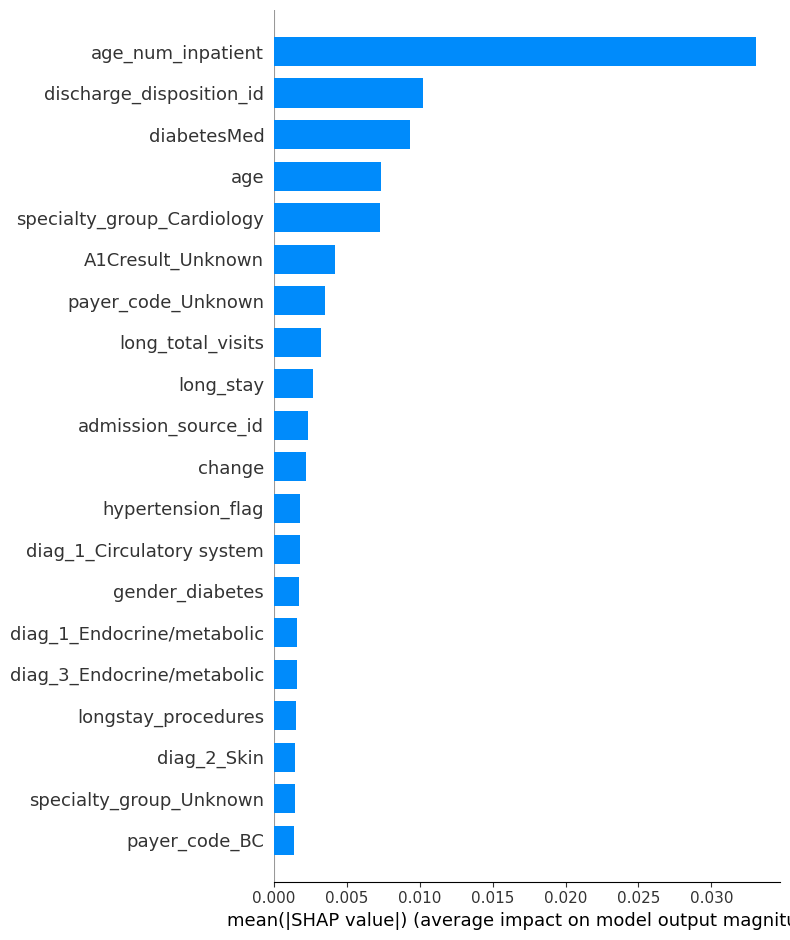

Первые 10 важных предикторов по mean(|SHAP|):
age_num_inpatient             0.033054
discharge_disposition_id      0.010204
diabetesMed                   0.009352
age                           0.007307
specialty_group_Cardiology    0.007293
A1Cresult_Unknown             0.004201
payer_code_Unknown            0.003497
long_total_visits             0.003238
long_stay                     0.002705
admission_source_id           0.002365
dtype: float64


In [121]:
X_background = X_train_final.sample(min(100, len(X_train_final)), random_state=42)
X_explain = X_val_final.sample(min(50, len(X_val_final)), random_state=10)

feature_names = X_explain.columns.tolist()

def predict_fn(X):
    X_df = pd.DataFrame(X, columns=feature_names)
    return final_model.predict_proba(X_df)[:, 1]

explainer = shap.Explainer(
    predict_fn,
    X_background,
    algorithm='permutation'
)

shap_values = explainer(X_explain)

shap.summary_plot(shap_values, X_explain, plot_type='bar')

shap_importance = pd.Series(
    np.abs(shap_values.values).mean(axis=0),
    index=X_explain.columns
).sort_values(ascending=False)

print('Первые 10 важных предикторов по mean(|SHAP|):')
print(shap_importance.head(10))


#### 4.2. Анализ 10 ключевых признаков


### Вывод

SHAP показывает вклад признаков в предсказания модели и не используется как доказательство причинно-следственной связи.


1: Какие действия можно рассмотреть после дополнительной клинической проверки модели?

1. Приоритизировать дополнительный мониторинг пациентов с высоким прогнозируемым риском.
2. Проверять историю госпитализаций и хронических состояний при планировании наблюдения.
3. Использовать прогноз как дополнительный сигнал, а не как самостоятельное основание для клинического решения.


### 5. Оценка условной стоимости ошибки модели


In [122]:
FP_COST = 1000
FN_COST = 10000


In [123]:
def validation_cost(model, dataset_name):
    X_train, X_val, _, y_train, y_val, _ = get_dataset_split(dataset_name)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    return fp * FP_COST + fn * FN_COST


Стоимость ошибок для случайного леса с лучшим recall


In [124]:
cost_rf_recall = validation_cost(rf_recall_info['best_estimator'], rf_recall_name)
print(cost_rf_recall)


17165000


Стоимость ошибок для случайного леса с лучшим F1


In [125]:
cost_rf_f1 = validation_cost(rf_f1_info['best_estimator'], rf_f1_name)
print(cost_rf_f1)


17165000


Дерево решений с лучшим recall


In [126]:
cost_tree_recall = validation_cost(tree_recall_info['best_estimator'], tree_recall_name)
print(cost_tree_recall)


19076000


Дерево решений с лучшим F1


In [127]:
cost_tree_f1 = validation_cost(tree_f1_info['best_estimator'], tree_f1_name)
print(cost_tree_f1)


17866000


Логистическая регрессия с лучшим recall


In [128]:
cost_lr_recall = validation_cost(lr_recall_info['best_estimator'], lr_recall_name)
print(cost_lr_recall)


18162000


Логистическая регрессия с лучшим F1


In [129]:
cost_lr_f1 = validation_cost(lr_f1_info['best_estimator'], lr_f1_name)
print(cost_lr_f1)


17654000


In [130]:
validation_costs = {
    'Random Forest recall': cost_rf_recall,
    'Random Forest F1': cost_rf_f1,
    'Decision Tree recall': cost_tree_recall,
    'Decision Tree F1': cost_tree_f1,
    'Logistic Regression recall': cost_lr_recall,
    'Logistic Regression F1': cost_lr_f1,
}
print(min(validation_costs.items(), key=lambda x: x[1]))


('Random Forest recall', np.int64(17165000))


### Порог для финальной модели подбирается на validation.


Изменение порога вероятности


Лучший порог по validation: 0.46
Условная стоимость на validation: 16331000
----------------------------------------------------------------------
Final Test Classification Report
              precision    recall  f1-score   support

           0      0.933     0.446     0.603     17898
           1      0.140     0.738     0.236      2195

    accuracy                          0.478     20093
   macro avg      0.537     0.592     0.420     20093
weighted avg      0.846     0.478     0.563     20093

----------------------------------------------------------------------
Confusion Matrix:
 [[7981 9917]
 [ 576 1619]]
----------------------------------------------------------------------
ROC AUC: 0.6313982728246701
Условная стоимость: 15677000


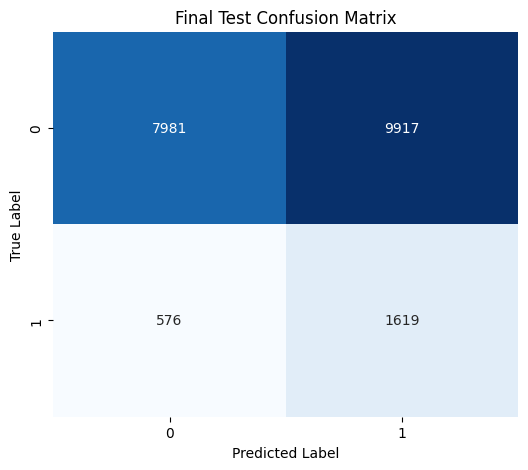

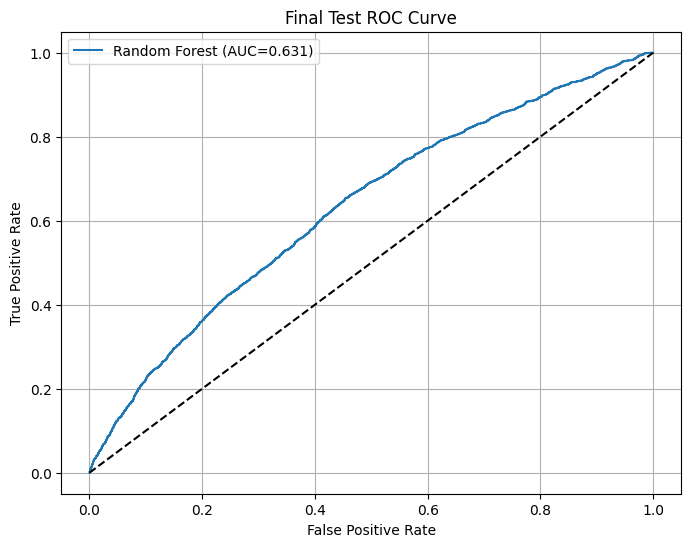

In [131]:
final_model.fit(X_train_final, y_train_final)

y_prob_val = final_model.predict_proba(X_val_final)[:, 1]
thresholds = np.linspace(0.1, 0.9, 50)
threshold_costs = []

for t in thresholds:
    y_pred_thresh = (y_prob_val >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val_final, y_pred_thresh).ravel()
    total_cost = fp * FP_COST + fn * FN_COST
    threshold_costs.append((t, total_cost, fp, fn))

best_threshold, best_val_cost, _, _ = min(threshold_costs, key=lambda x: x[1])
print(f"Лучший порог по validation: {best_threshold:.2f}")
print(f"Условная стоимость на validation: {best_val_cost}")

y_prob_test = final_model.predict_proba(X_test_final)[:, 1]
y_pred_test = (y_prob_test >= best_threshold).astype(int)

conf_matrix_test = confusion_matrix(y_test_final, y_pred_test)
tn, fp, fn, tp = conf_matrix_test.ravel()
test_cost = fp * FP_COST + fn * FN_COST
test_auc = roc_auc_score(y_test_final, y_prob_test)

print('-'*70)
print('Final Test Classification Report')
print(classification_report(y_test_final, y_pred_test, digits=3, zero_division=0))
print('-'*70)
print('Confusion Matrix:\n', conf_matrix_test)
print('-'*70)
print('ROC AUC:', test_auc)
print('Условная стоимость:', test_cost)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix_test, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Final Test Confusion Matrix')
plt.show()

fpr, tpr, _ = roc_curve(y_test_final, y_prob_test)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'{final_family} (AUC={test_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Final Test ROC Curve')
plt.legend()
plt.grid(True)
plt.show()
